# Lec2 — Gaussian Kernel Density Estimation
### From a Single Gaussian to Fitting Data

This notebook builds from scratch — first understanding what a Gaussian is, then learning to fit one to data using gradient descent. We start with the Gaussian PDF and its two parameters, draw samples from it, visually compare candidate fits, formalize the notion of likelihood, and finally let PyTorch's Adam optimizer automatically discover the best parameters by minimizing the negative log-likelihood. By the end, you will see exactly how Maximum Likelihood Estimation works in practice — and appreciate why it sets the stage for more flexible density models like Kernel Density Estimation.

## Part 1 — Introducing the Gaussian

The Gaussian (or Normal) distribution is the most fundamental probability distribution in all of statistics and machine learning. It appears everywhere: measurement noise, biological variation, financial returns, and as the limiting distribution of averages (Central Limit Theorem). Its probability density function is:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

There are exactly two parameters:
- **μ (mu)** — controls the *center* of the distribution, i.e., where the peak sits on the x-axis.
- **σ (sigma)** — controls the *width*, i.e., how spread out the distribution is. Large σ means the curve is wide and flat; small σ means it is tall and narrow.

Two knobs. That's all it takes.

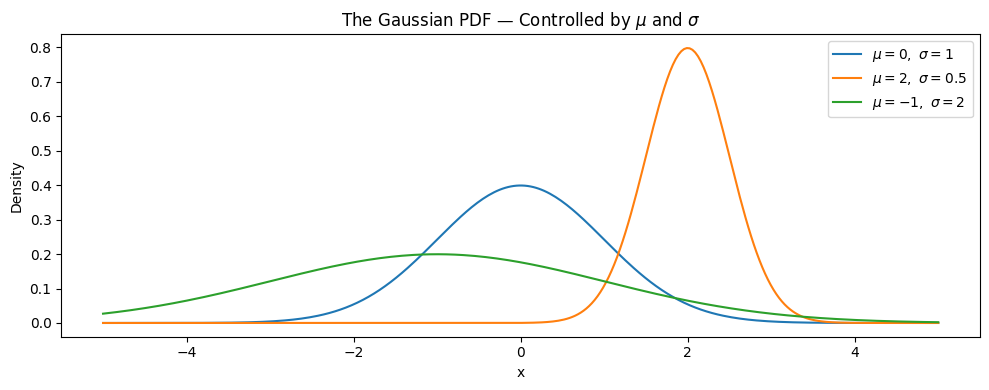

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_pdf(x, mu, sigma):
    """Gaussian PDF computed manually from the formula."""
    coeff = 1.0 / (sigma * np.sqrt(2 * np.pi))
    exponent = -0.5 * ((x - mu) / sigma) ** 2
    return coeff * np.exp(exponent)

x = np.linspace(-5, 5, 300)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(x, gaussian_pdf(x, mu=0, sigma=1),   label=r'$\mu=0,\ \sigma=1$')
ax.plot(x, gaussian_pdf(x, mu=2, sigma=0.5), label=r'$\mu=2,\ \sigma=0.5$')
ax.plot(x, gaussian_pdf(x, mu=-1, sigma=2),  label=r'$\mu=-1,\ \sigma=2$')

ax.set_title(r'The Gaussian PDF — Controlled by $\mu$ and $\sigma$')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## Part 2 — Drawing Samples

A distribution isn't just a curve — it tells us *where data is likely to appear*.

If we have a Gaussian with μ=3, σ=1, samples will cluster around 3. Values far from 3 are possible but rare — the probability drops off exponentially as we move away from the center. The tighter σ is, the more the samples pile up near μ.

Let's draw some.

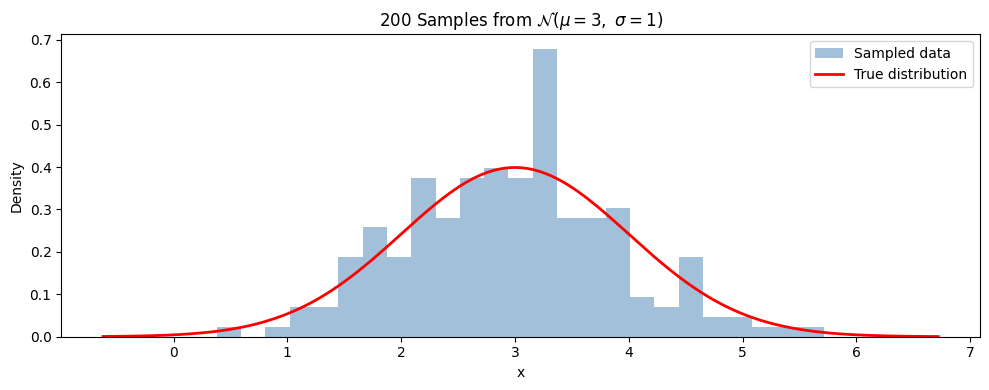

In [3]:
np.random.seed(42)

mu_true = 3.0
sigma_true = 1.0
N = 200

data = np.random.normal(mu_true, sigma_true, N)

x_plot = np.linspace(data.min() - 1, data.max() + 1, 300)

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(data, bins=25, density=True, alpha=0.5, color='steelblue', label='Sampled data')
ax.plot(x_plot, gaussian_pdf(x_plot, mu_true, sigma_true),
        color='red', linewidth=2, label='True distribution')

ax.set_title(r'200 Samples from $\mathcal{N}(\mu=3,\ \sigma=1)$')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## Part 3 — Moving μ and σ: Some Curves Fit, Some Don't

Now here's the key question: if we *didn't know* the true μ and σ, could we guess them just by looking at the data?

Let's try different (μ, σ) values and see which curve best matches our samples.

Some will be way off. Some will look pretty good.

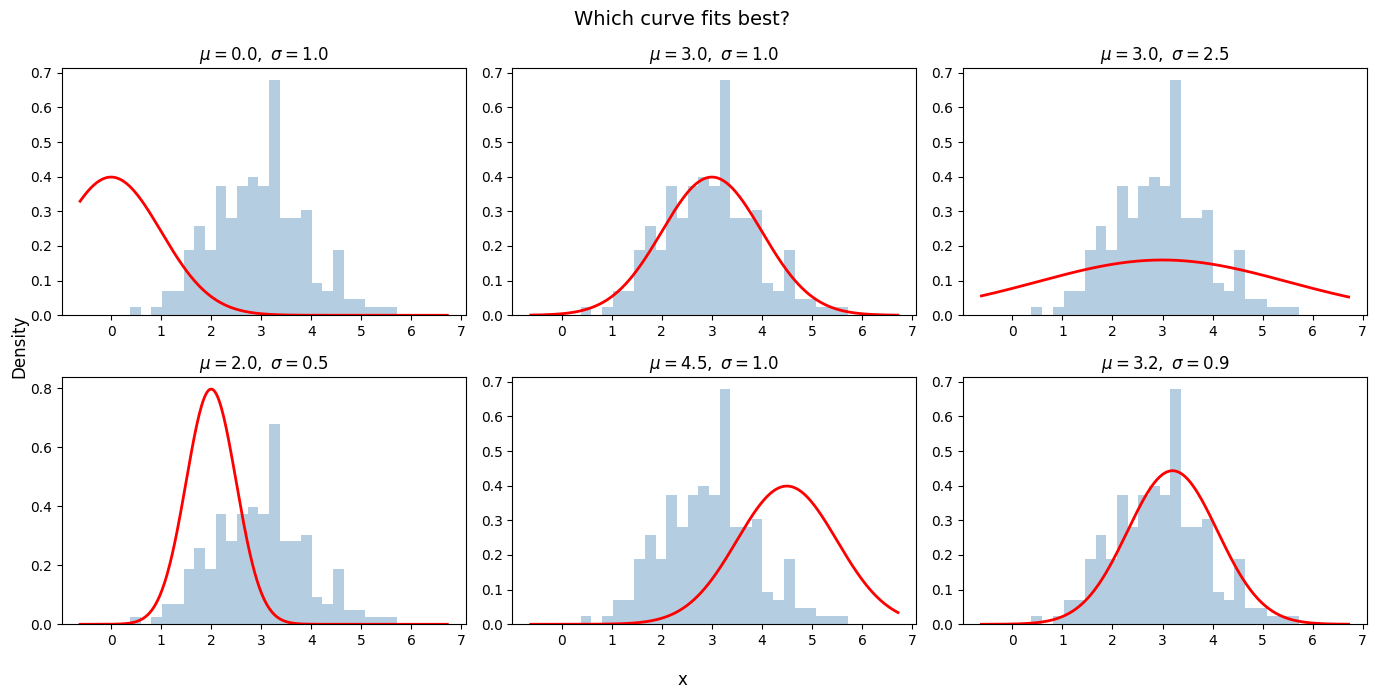

In [4]:
candidates = [(0.0, 1.0), (3.0, 1.0), (3.0, 2.5), (2.0, 0.5), (4.5, 1.0), (3.2, 0.9)]

x_plot = np.linspace(data.min() - 1, data.max() + 1, 300)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, (mu, sigma) in zip(axes.flat, candidates):
    ax.hist(data, bins=25, density=True, alpha=0.4, color='steelblue')
    ax.plot(x_plot, gaussian_pdf(x_plot, mu, sigma), color='red', linewidth=2)
    ax.set_title(f'$\\mu={mu},\ \\sigma={sigma}$')

fig.supxlabel('x', fontsize=12)
fig.supylabel('Density', fontsize=12)
plt.suptitle('Which curve fits best?', fontsize=14)
plt.tight_layout()
plt.show()

## Part 4 — Formulating the Likelihood

Looking at plots by eye works for 6 candidates. But we need something systematic.

The **log-likelihood** gives us a scalar score for how well a Gaussian with parameters (μ, σ) explains the observed data:

$$\log \mathcal{L}(\mu, \sigma) = \sum_{i=1}^{N} \log f(x_i \mid \mu, \sigma)$$

Substituting in the Gaussian PDF and simplifying:

$$= -\frac{N}{2}\log(2\pi) - N\log\sigma - \frac{1}{2\sigma^2}\sum_{i=1}^{N}(x_i - \mu)^2$$

The higher the log-likelihood, the better the Gaussian explains the data.

Our goal: find μ and σ that *maximize* this — equivalently, *minimize* the negative log-likelihood (NLL).

In [5]:
def neg_log_likelihood(mu, sigma, data):
    """Negative log-likelihood of data under N(mu, sigma)."""
    N = len(data)
    nll = (
        0.5 * N * np.log(2 * np.pi)
        + N * np.log(sigma)
        + 0.5 * np.sum((data - mu) ** 2) / (sigma ** 2)
    )
    return nll

candidates = [(0.0, 1.0), (3.0, 1.0), (3.0, 2.5), (2.0, 0.5), (4.5, 1.0), (3.2, 0.9)]

nll_values = [(mu, sigma, neg_log_likelihood(mu, sigma, data)) for mu, sigma in candidates]
best = min(nll_values, key=lambda t: t[2])

print(f"{'Candidate':<18} {'NLL':>10}")
print("-" * 30)
for mu, sigma, nll in nll_values:
    marker = "  <- best" if (mu, sigma) == (best[0], best[1]) else ""
    print(f"({mu}, {sigma}){'':>6} {nll:>10.2f}{marker}")

print(f"\nBest candidate by NLL: \u03bc={best[0]}, \u03c3={best[1]}")

Candidate                 NLL
------------------------------
(0.0, 1.0)          1145.73
(3.0, 1.0)           270.20  <- best
(3.0, 2.5)           380.87
(2.0, 0.5)           758.18
(4.5, 1.0)           507.43
(3.2, 0.9)           276.35

Best candidate by NLL: μ=3.0, σ=1.0


## Part 5 — Gradient Descent to Fit the Gaussian

Instead of trying a handful of candidates, let's let the math find the answer automatically.

We'll use **gradient descent**: start with a bad guess, compute the gradient of NLL with respect to μ and σ, and take small steps in the direction that reduces NLL.

We optimize `log_sigma` instead of `sigma` directly — this ensures σ stays positive throughout training without any explicit constraints, and makes the loss landscape smoother.

Watch the Gaussian curve crawl toward the data.

In [6]:
import torch
import numpy as np

x = torch.tensor(data, dtype=torch.float32)

# ── Initialization ────────────────────────────────────────────────────────────
mu       = torch.tensor(0.0, requires_grad=True)   # bad starting guess
log_sigma = torch.tensor(0.0, requires_grad=True)  # optimise log σ for stability

optimizer = torch.optim.Adam([mu, log_sigma], lr=0.05)

n_epochs     = 300
record_every = 30
history      = []   # (epoch, mu, sigma, nll)

# ── Training loop ─────────────────────────────────────────────────────────────
for epoch in range(n_epochs):
    sigma = torch.exp(log_sigma)
    nll   = (
        0.5 * torch.log(2 * torch.tensor(np.pi))
        + log_sigma
        + 0.5 * ((x - mu) ** 2 / sigma ** 2).mean()
    )
    optimizer.zero_grad()
    nll.backward()
    optimizer.step()

    if epoch % record_every == 0 or epoch == n_epochs - 1:
        history.append((epoch, mu.item(), torch.exp(log_sigma).item(), nll.item()))

# ── Training log ──────────────────────────────────────────────────────────────
print(f"{'Epoch':>6}  {'μ (mu)':>10}  {'σ (sigma)':>10}  {'NLL':>10}")
print("-" * 44)
for epoch, mu_val, sigma_val, nll_val in history:
    print(f"{epoch:>6}  {mu_val:>10.4f}  {sigma_val:>10.4f}  {nll_val:>10.4f}")

print(f"\nLearned  μ = {history[-1][1]:.4f},  σ = {history[-1][2]:.4f}")
print(f"True     μ = 3.0000,  σ = 1.0000")


 Epoch      μ (mu)   σ (sigma)         NLL
--------------------------------------------
     0      0.0500      1.0513      5.7287
    30      1.1211      2.4646      2.1749
    60      1.6300      2.1697      1.9816
    90      2.1959      1.5625      1.6727
   120      2.8080      1.0914      1.3831
   150      2.9932      0.9118      1.3460
   180      2.9524      0.9273      1.3450
   210      2.9605      0.9297      1.3449
   240      2.9590      0.9284      1.3449
   270      2.9593      0.9287      1.3449
   299      2.9592      0.9287      1.3449

Learned  μ = 2.9592,  σ = 0.9287
True     μ = 3.0000,  σ = 1.0000


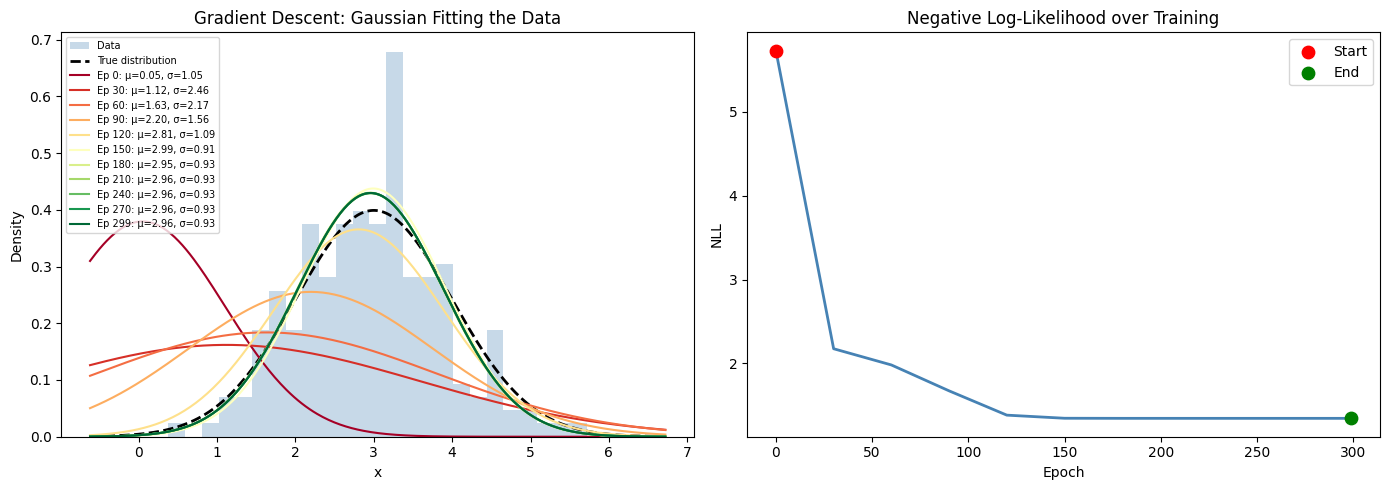

In [7]:
# ── Static snapshot plot ─────────────────────────────────────────────────────
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5))

x_plot = np.linspace(data.min() - 1, data.max() + 1, 300)

ax_left.hist(data, bins=25, density=True, alpha=0.3, color='steelblue', label='Data')
ax_left.plot(x_plot, gaussian_pdf(x_plot, mu_true, sigma_true),
             'k--', linewidth=2, label='True distribution')

n_snapshots = len(history)
cmap   = plt.cm.RdYlGn
colors = [cmap(i / (n_snapshots - 1)) for i in range(n_snapshots)]

for i, (epoch, mu_val, sigma_val, nll_val) in enumerate(history):
    ax_left.plot(
        x_plot, gaussian_pdf(x_plot, mu_val, sigma_val),
        color=colors[i], linewidth=1.5,
        label=f'Ep {epoch}: μ={mu_val:.2f}, σ={sigma_val:.2f}'
    )

ax_left.set_title('Gradient Descent: Gaussian Fitting the Data')
ax_left.set_xlabel('x')
ax_left.set_ylabel('Density')
ax_left.legend(fontsize=7, loc='upper left')

epochs_rec = [h[0] for h in history]
nlls_rec   = [h[3] for h in history]
ax_right.plot(epochs_rec, nlls_rec, color='steelblue', linewidth=2)
ax_right.scatter([epochs_rec[0]],  [nlls_rec[0]],  color='red',   s=80, zorder=5, label='Start')
ax_right.scatter([epochs_rec[-1]], [nlls_rec[-1]], color='green', s=80, zorder=5, label='End')
ax_right.set_title('Negative Log-Likelihood over Training')
ax_right.set_xlabel('Epoch')
ax_right.set_ylabel('NLL')
ax_right.legend()

plt.tight_layout()
plt.show()


### Animation — Watching μ and σ Converge

The cell below saves an animated GIF (`training_animation.gif`) showing frame-by-frame how
the learned Gaussian evolves from the bad starting guess toward the true distribution.
Each frame corresponds to one recorded checkpoint.


In [ ]:
import matplotlib.animation as animation
from IPython.display import Image as IPImage, display

# ── Build animation frames ────────────────────────────────────────────────────
fig_anim, ax_anim = plt.subplots(figsize=(8, 4))

x_plot = np.linspace(data.min() - 1, data.max() + 1, 300)
cmap   = plt.cm.RdYlGn

def draw_frame(i):
    ax_anim.clear()
    epoch, mu_val, sigma_val, nll_val = history[i]
    color = cmap(i / (len(history) - 1))

    ax_anim.hist(data, bins=25, density=True, alpha=0.3, color='steelblue')
    ax_anim.plot(x_plot, gaussian_pdf(x_plot, mu_true, sigma_true),
                 'k--', linewidth=2, label='True N(3, 1)')
    ax_anim.plot(x_plot, gaussian_pdf(x_plot, mu_val, sigma_val),
                 color=color, linewidth=2.5,
                 label=f'Epoch {epoch}:  μ={mu_val:.3f},  σ={sigma_val:.3f}')

    ax_anim.set_xlim(x_plot[0], x_plot[-1])
    ax_anim.set_ylim(0, 0.65)
    ax_anim.set_title(f'Gradient Descent — Epoch {epoch}   NLL={nll_val:.2f}')
    ax_anim.set_xlabel('x')
    ax_anim.set_ylabel('Density')
    ax_anim.legend(loc='upper left', fontsize=9)

ani = animation.FuncAnimation(
    fig_anim, draw_frame,
    frames=len(history), interval=400, repeat=True
)

gif_path = 'training_animation.gif'
ani.save(gif_path, writer='pillow', fps=2)
plt.close(fig_anim)

print(f'Saved: {gif_path}')
display(IPImage(filename=gif_path))


---
## Part 6 — What If the Data Is Not Gaussian? Kernel Density Estimation

### Parametric vs. Non-Parametric Approaches

Everything we have done so far belongs to the **parametric** family.
Here is how the two families differ:

| | Parametric | Non-parametric |
|---|---|---|
| **Core idea** | Assume a fixed functional form for $p(x)$ | Make no assumption about the shape of $p(x)$ |
| **Parameters** | Fixed, finite number (e.g. $\mu, \sigma$) | Grows with the data (e.g. $N$ kernels in KDE) |
| **Fitting** | MLE, gradient descent | Data-driven rules (e.g. Silverman's rule) |
| **Risk** | Wrong if assumed shape doesn't match reality | Needs more data; harder to interpret |
| **Conventional examples** | Gaussian, GMM, Linear Regression, Logistic Regression, Neural Networks | KDE, $k$-NN, Empirical Distribution |
| **In Generative AI** | VAE, GAN, Diffusion models | KDE — the simplest non-parametric generative model |

### Why Parametric Fails on Non-Gaussian Data

MLE always returns one bell curve — but if the data has **two clusters** or a skewed tail,
the model is wrong by construction, no matter how good the optimizer is.

### The Non-Parametric MLE: Empirical Distribution

What if we make **no assumption at all** about the shape of $p(x)$?

The MLE with no shape constraint is the **empirical distribution**:
place probability mass $\frac{1}{N}$ at each observed data point, zero everywhere else:

$$\hat{p}_{\text{empirical}}(x) = \frac{1}{N}\sum_{i=1}^{N} \delta(x - x_i)$$

This maximizes the likelihood of the observed data without any parametric assumption.

**Problem:** a sum of Dirac spikes is infinitely spiky — zero everywhere except exactly
at the training points, making it useless for evaluating or generating new data.
The figure below shows what this looks like.

### The Fix: Smooth Each Spike with a Gaussian → KDE

Replace each Dirac spike $\delta(x - x_i)$ with a small Gaussian bump of width $h$:

$$\boxed{\hat{p}(x) = \frac{1}{N} \sum_{i=1}^{N} \mathcal{N}(x \mid x_i,\, h)}$$

This is **Kernel Density Estimation**. The figure below shows the full progression:
raw data → empirical distribution (Dirac spikes) → KDE (smooth curve).

In [ ]:
# ── From raw data → Dirac spikes → KDE ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)
demo_pts = np.concatenate([np.random.normal(-2.0, 0.4, 7),
                            np.random.normal( 2.0, 0.4, 7)])
N_demo  = len(demo_pts)
x_plot  = np.linspace(-5, 5, 500)
h_demo  = 0.4

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

# ── Panel 1: raw data points ──────────────────────────────────────────────────
axes[0].scatter(demo_pts, np.zeros(N_demo), s=90, color='steelblue', zorder=5)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_ylim(-0.03, 0.55)
axes[0].set_title('① Raw data\n(N observations on the number line)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Probability / density')

# ── Panel 2: empirical distribution — Dirac spikes ───────────────────────────
axes[1].axhline(0, color='black', lw=0.8)
for xi in demo_pts:
    axes[1].annotate('', xy=(xi, 1/N_demo), xytext=(xi, 0),
                     arrowprops=dict(arrowstyle='->', color='tomato', lw=2))
    axes[1].scatter([xi], [1/N_demo], color='tomato', s=60, zorder=5)
axes[1].scatter(demo_pts, np.zeros(N_demo), s=90, color='steelblue', zorder=5)
axes[1].set_ylim(-0.03, 0.55)
axes[1].set_title('② Empirical distribution\n'
                  r'$\hat{p}(x)=\frac{1}{N}\sum_i\delta(x-x_i)$  — Dirac spikes at each point')
axes[1].set_xlabel('x')
axes[1].text(0.5, 0.92, f'mass = 1/N = {1/N_demo:.2f} per spike',
             transform=axes[1].transAxes, ha='center', fontsize=9, color='tomato')

# ── Panel 3: KDE — smooth the spikes ─────────────────────────────────────────
kernels   = np.array([(1/(h_demo*np.sqrt(2*np.pi)))*np.exp(-0.5*((x_plot-xi)/h_demo)**2)
                      for xi in demo_pts])
kde_curve = kernels.mean(axis=0)

axes[2].axhline(0, color='black', lw=0.8)
for kernel in kernels:
    axes[2].plot(x_plot, kernel/N_demo, color='steelblue', lw=0.8, alpha=0.3)
axes[2].plot(x_plot, kde_curve, color='steelblue', lw=2.5,
             label=f'KDE  (h={h_demo})')
axes[2].scatter(demo_pts, np.zeros(N_demo), s=90, color='steelblue', zorder=5)
axes[2].set_ylim(-0.03, 0.55)
axes[2].set_title('③ KDE — replace each spike with a Gaussian\n'
                  r'$\hat{p}(x)=\frac{1}{N}\sum_i\mathcal{N}(x\mid x_i,h)$')
axes[2].set_xlabel('x'); axes[2].legend(fontsize=9)

plt.suptitle('Raw Data  →  Empirical Distribution (Dirac Spikes)  →  KDE (Smooth)',
             fontsize=12)
plt.tight_layout(); plt.show()

### The Bandwidth $h$ — Theoretical Formulation

The shorthand $\mathcal{N}(x \mid x_i,\, h)$ means a Gaussian centred at $x_i$
with **standard deviation $h$**. Writing it out in full:

$$\mathcal{N}(x \mid x_i,\, h)
= \frac{1}{h\sqrt{2\pi}} \exp\!\left(-\frac{(x - x_i)^2}{2h^2}\right)$$

Substituting into the KDE formula gives the full expression:

$$\hat{p}(x)
= \frac{1}{N} \sum_{i=1}^{N}
  \frac{1}{h\sqrt{2\pi}} \exp\!\left(-\frac{(x - x_i)^2}{2h^2}\right)$$

**$h$ is literally the standard deviation of each kernel:**

- The $\frac{1}{h\sqrt{2\pi}}$ prefactor ensures each kernel integrates to 1
  (it gets shorter as $h$ grows — to keep the area fixed).
- The $2h^2$ in the exponent controls how fast the kernel decays away from $x_i$:
  large $h$ → slow decay → wide bump; small $h$ → fast decay → narrow spike.

**Two limiting cases:**

| Limit | Kernel shape | KDE result |
|---|---|---|
| $h \to 0$ | $\mathcal{N}(x\mid x_i, h) \to \delta(x - x_i)$ | Recovers the spiky empirical distribution |
| $h \to \infty$ | Kernel flattens to near-zero everywhere | Density smears out, all structure lost |

The cell below shows what a **single kernel** looks like for different $h$,
before combining $N$ of them into the full KDE.

/var/folders/jn/fl0qtdwx3lsb25cfxsc3pt700000gq/T/ipykernel_41595/1362970157.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(k, x_plot)


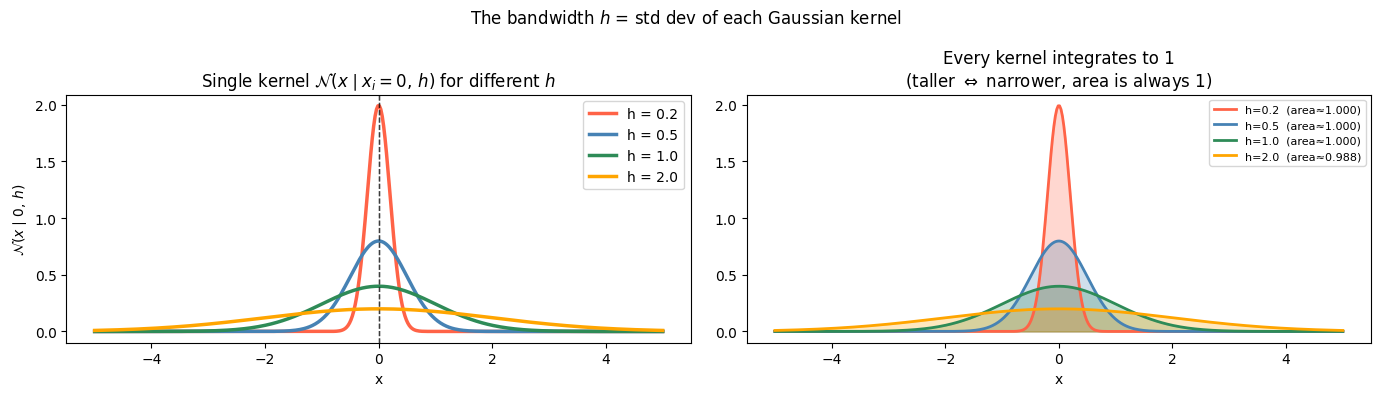

h    peak height    approx area
0.2          1.995    1.0000
0.5          0.798    1.0000
1.0          0.399    1.0000
2.0          0.199    0.9876

All kernels integrate to 1 — h only reshapes them, not their total mass.


In [6]:
# ── A single Gaussian kernel N(x | x_i, h) at x_i = 0, for different h ──────
x_plot = np.linspace(-5, 5, 400)
xi     = 0.0    # fix the kernel centre at 0

h_vals = [0.2, 0.5, 1.0, 2.0]
colors = ['tomato', 'steelblue', 'seagreen', 'orange']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: overlay all kernels — same centre, different widths
for h_val, color in zip(h_vals, colors):
    k = (1 / (h_val * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_plot - xi) / h_val) ** 2)
    axes[0].plot(x_plot, k, color=color, lw=2.5, label=f'h = {h_val}')
    axes[0].axvline(xi, color='black', lw=1, ls='--', alpha=0.3)

axes[0].set_title(r'Single kernel $\mathcal{N}(x \mid x_i=0,\, h)$ for different $h$')
axes[0].set_xlabel('x')
axes[0].set_ylabel(r'$\mathcal{N}(x \mid 0,\, h)$')
axes[0].legend()

# Right: show that all kernels integrate to 1 despite different shapes
areas = []
for h_val, color in zip(h_vals, colors):
    k    = (1 / (h_val * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_plot - xi) / h_val) ** 2)
    area = np.trapz(k, x_plot)
    areas.append(area)
    axes[1].fill_between(x_plot, k, alpha=0.25, color=color)
    axes[1].plot(x_plot, k, color=color, lw=2, label=f'h={h_val}  (area≈{area:.3f})')

axes[1].set_title('Every kernel integrates to 1\n'
                  r'(taller $\Leftrightarrow$ narrower, area is always 1)')
axes[1].set_xlabel('x'); axes[1].legend(fontsize=8)

plt.suptitle(r'The bandwidth $h$ = std dev of each Gaussian kernel', fontsize=12)
plt.tight_layout(); plt.show()

print('h    peak height    approx area')
for h_val, area in zip(h_vals, areas):
    peak = 1 / (h_val * np.sqrt(2 * np.pi))
    print(f'{h_val:<6}  {peak:>10.3f}    {area:.4f}')
print('\nAll kernels integrate to 1 — h only reshapes them, not their total mass.')

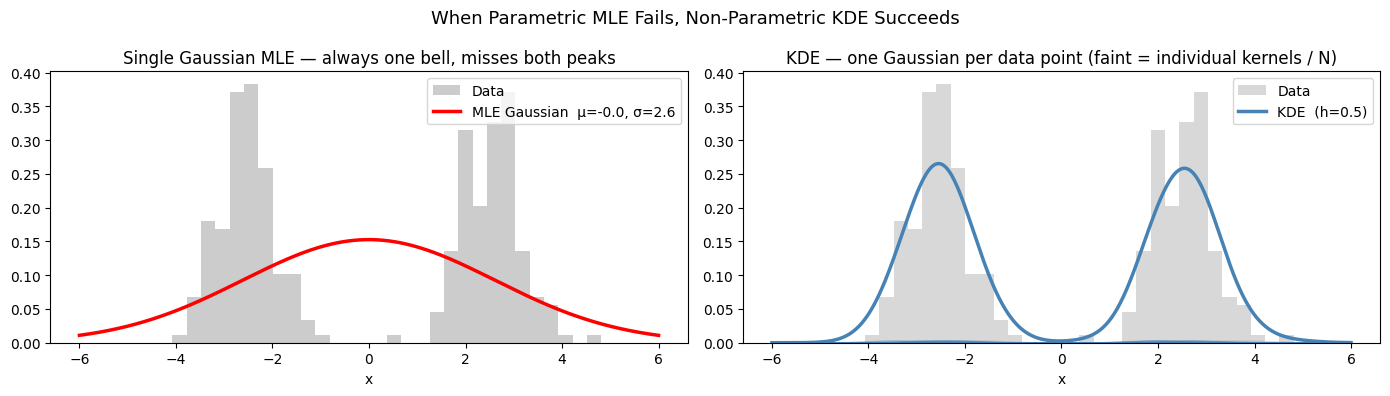

N = 300 data points
MLE: one Gaussian  μ=-0.00, σ=2.61 — misses both peaks
KDE: 300 Gaussians (one per data point), bandwidth h=0.5 — captures both peaks


In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ── Bimodal data: a single Gaussian MLE will fail ────────────────────────────
data_bimodal = np.concatenate([
    np.random.normal(-2.5, 0.6, 150),
    np.random.normal( 2.5, 0.6, 150)
])
N = len(data_bimodal)

# ── MLE: single Gaussian ─────────────────────────────────────────────────────
mu_mle    = data_bimodal.mean()
sigma_mle = data_bimodal.std()          # MLE std divides by N

# ── KDE: one Gaussian per training point ─────────────────────────────────────
h = 0.5

def gaussian_pdf_local(x, mu, sigma):
    return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

x_plot    = np.linspace(-6, 6, 400)
mle_curve = gaussian_pdf_local(x_plot, mu_mle, sigma_mle)

# KDE = average of N Gaussians, one centred at each data point
kernels   = np.array([gaussian_pdf_local(x_plot, xi, h) for xi in data_bimodal])
kde_curve = kernels.mean(axis=0)         # shape (400,)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: MLE fails
axes[0].hist(data_bimodal, bins=30, density=True, alpha=0.4, color='gray', label='Data')
axes[0].plot(x_plot, mle_curve, 'r-', lw=2.5,
             label=f'MLE Gaussian  μ={mu_mle:.1f}, σ={sigma_mle:.1f}')
axes[0].set_title('Single Gaussian MLE — always one bell, misses both peaks')
axes[0].set_xlabel('x'); axes[0].legend()

# Right: KDE — show individual kernels + final curve
axes[1].hist(data_bimodal, bins=30, density=True, alpha=0.3, color='gray', label='Data')
for kernel in kernels[::10]:             # show every 10th kernel to avoid clutter
    axes[1].plot(x_plot, kernel / N, color='steelblue', lw=0.7, alpha=0.25)
axes[1].plot(x_plot, kde_curve, 'steelblue', lw=2.5, label=f'KDE  (h={h})')
axes[1].set_title(f'KDE — one Gaussian per data point (faint = individual kernels / N)')
axes[1].set_xlabel('x'); axes[1].legend()

plt.suptitle('When Parametric MLE Fails, Non-Parametric KDE Succeeds', fontsize=13)
plt.tight_layout(); plt.show()

print(f'N = {N} data points')
print(f'MLE: one Gaussian  μ={mu_mle:.2f}, σ={sigma_mle:.2f} — misses both peaks')
print(f'KDE: {N} Gaussians (one per data point), bandwidth h={h} — captures both peaks')

### Part 6.1 — The Effect of h: Which KDE Fits?

In Part 3 we slid $\mu$ and $\sigma$ around and asked: *which single Gaussian fits best?*
For KDE the only free parameter is the **bandwidth $h$**.
Let's do the same thing — try several values of $h$ and see what happens to the density.


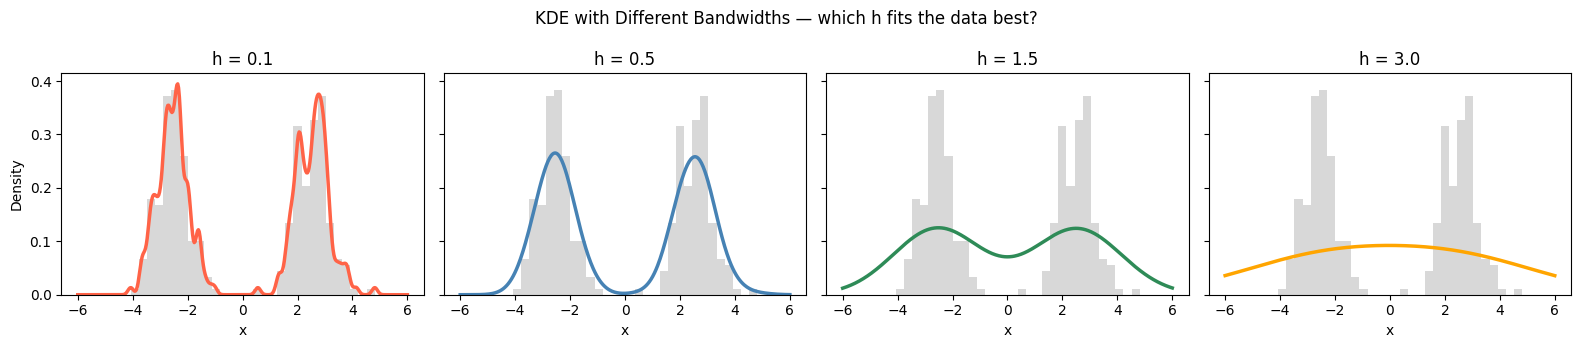

h = 0.1 → spiky, overfit (every data point is its own spike)
h = 0.5 → smooth, captures the two clusters clearly
h = 1.5 → too smooth, the two clusters start merging
h = 3.0 → oversmoothed, looks like a single wide Gaussian again


In [8]:
h_values = [0.1, 0.5, 1.5, 3.0]
colors   = ['tomato', 'steelblue', 'seagreen', 'orange']

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, h_val, color in zip(axes, h_values, colors):
    kernels_h = np.array([gaussian_pdf_local(x_plot, xi, h_val) for xi in data_bimodal])
    kde_h     = kernels_h.mean(axis=0)

    ax.hist(data_bimodal, bins=30, density=True, alpha=0.3, color='gray')
    ax.plot(x_plot, kde_h, color=color, lw=2.5)
    ax.set_title(f'h = {h_val}', fontsize=12)
    ax.set_xlabel('x')

axes[0].set_ylabel('Density')
plt.suptitle('KDE with Different Bandwidths — which h fits the data best?', fontsize=12)
plt.tight_layout(); plt.show()

print('h = 0.1 → spiky, overfit (every data point is its own spike)')
print('h = 0.5 → smooth, captures the two clusters clearly')
print('h = 1.5 → too smooth, the two clusters start merging')
print('h = 3.0 → oversmoothed, looks like a single wide Gaussian again')

### Part 6.2 — Can We Use Gradient Descent to Find h? (Naive Attempt)

In Part 5 we optimized $\mu$ and $\sigma$ by minimizing the **negative log-likelihood**.
Can we do the same for KDE — just optimize $h$ by maximizing:

$$\ell_{\text{naive}}(h) = \sum_{i=1}^{N} \log \hat{p}(x_i)
= \sum_{i=1}^{N} \log \left[\frac{1}{N}\sum_{j=1}^{N} \mathcal{N}(x_i \mid x_j,\, h)\right]$$

This looks natural — evaluate the KDE density at every training point
and maximize how likely they are. Let's try it and see what happens.


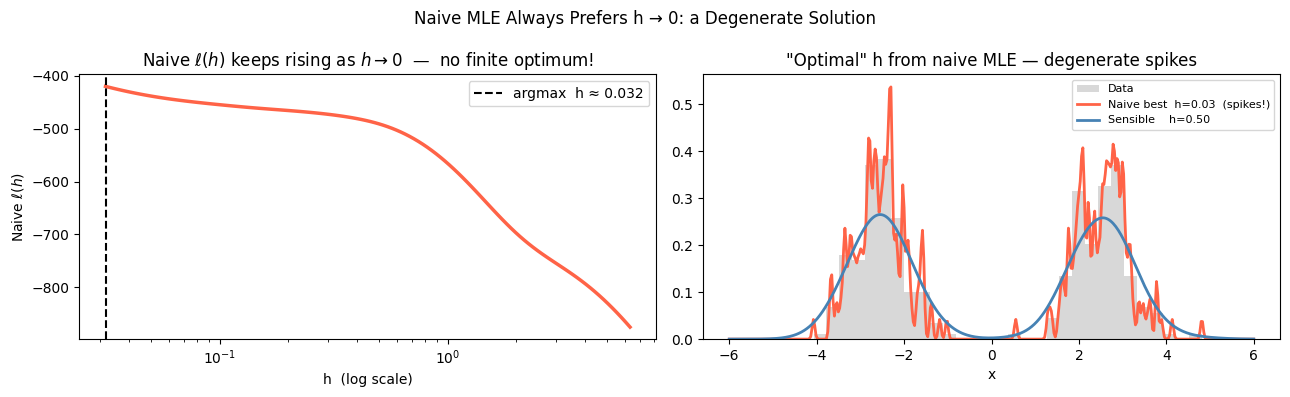

Why does naive MLE always prefer h → 0?
  When h → 0,  N(xi | xi, h) = 1 / (h √2π) → ∞
  The self-kernel of x_i dominates the sum and drives ℓ → ∞.
  Naive MLE cheats: it rewards the model for memorising the training points.


In [12]:
# ── Naive log-likelihood: evaluate KDE at every training point ───────────────
h_grid_naive = np.logspace(-1.5, 0.8, 120)   # from ~0.03 to ~6.3
naive_ll = []

for h_val in h_grid_naive:
    ll = 0.0
    for xi in data_bimodal:
        # Naive: x_i IS included in its own KDE sum
        p_xi = np.mean([gaussian_pdf_local(xi, xj, h_val) for xj in data_bimodal])
        ll  += np.log(p_xi + 1e-300)
    naive_ll.append(ll)

naive_ll   = np.array(naive_ll)
best_idx   = np.argmax(naive_ll)
best_h_naive = h_grid_naive[best_idx]

x_plot = np.linspace(-6, 6, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — ℓ(h) vs h: monotonically increases as h → 0
axes[0].semilogx(h_grid_naive, naive_ll, 'tomato', lw=2.5)
axes[0].axvline(best_h_naive, color='black', ls='--', lw=1.5,
                label=f'argmax  h ≈ {best_h_naive:.3f}')
axes[0].set_xlabel('h  (log scale)')
axes[0].set_ylabel(r'Naive $\ell(h)$')
axes[0].set_title(r'Naive $\ell(h)$ keeps rising as $h \to 0$  —  no finite optimum!')
axes[0].legend()

# Right — what the 'optimal' (tiny h) KDE looks like
h_tiny   = h_grid_naive[0]
kde_tiny = np.mean([gaussian_pdf_local(x_plot, xi, h_tiny)
                    for xi in data_bimodal], axis=0)
kde_good = np.mean([gaussian_pdf_local(x_plot, xi, 0.5)
                    for xi in data_bimodal], axis=0)
axes[1].hist(data_bimodal, bins=30, density=True, alpha=0.3, color='gray', label='Data')
axes[1].plot(x_plot, kde_tiny, 'tomato',    lw=2,   label=f'Naive best  h={h_tiny:.2f}  (spikes!)')
axes[1].plot(x_plot, kde_good, 'steelblue', lw=2,   label='Sensible    h=0.50')
axes[1].set_title('"Optimal" h from naive MLE — degenerate spikes')
axes[1].set_xlabel('x'); axes[1].legend(fontsize=8)

plt.suptitle('Naive MLE Always Prefers h → 0: a Degenerate Solution', fontsize=12)
plt.tight_layout(); plt.show()

print('Why does naive MLE always prefer h → 0?')
print(f'  When h → 0,  N(xi | xi, h) = 1 / (h √2π) → ∞')
print(f'  The self-kernel of x_i dominates the sum and drives ℓ → ∞.')
print(f'  Naive MLE cheats: it rewards the model for memorising the training points.')


### Why Naive MLE Fails: The Self-Evaluation Problem

When we evaluate $\hat{p}(x_i)$ **at a training point $x_i$**, its own kernel
$\mathcal{N}(x_i \mid x_i, h)$ is always centred exactly on it:

$$\mathcal{N}(x_i \mid x_i, h) = \frac{1}{h\sqrt{2\pi}}
\exp\!\left(-\frac{0^2}{2h^2}\right) = \frac{1}{h\sqrt{2\pi}} \xrightarrow{h\to 0} \infty$$

No matter how bad the fit is everywhere else, shrinking $h$ always increases this term.
So the naive likelihood is **never** maximized at a finite $h$ — gradient descent
will always push $h$ toward zero, recovering the degenerate empirical distribution.

**The fix:** when scoring $x_i$, **exclude $x_i$ from its own KDE**.
This is called **leave-one-out** scoring, and it gives an honest estimate
of how well the KDE generalises to data it has not seen.


### Part 6.3 — Scoring h with Log-Likelihood

In Part 4 we scored each Gaussian candidate with the log-likelihood:
$$\ell(\mu,\sigma) = \sum_{i=1}^N \log \mathcal{N}(x_i \mid \mu, \sigma)$$

We can do the same for KDE — score how well the estimated density
explains the data by evaluating the KDE at each training point:

$$\ell(h) = \sum_{i=1}^N \log \hat{p}(x_i)$$

**One subtlety:** if we include $x_i$ in its own KDE, the kernel at $x_i$ is always
centred exactly on $x_i$ and contributes a large term regardless of $h$.
This unfairly favours very small $h$.

The fix is **leave-one-out**: when scoring point $x_i$, compute the KDE using
all *other* points $x_{j \neq i}$. This gives an honest measure of how well
the KDE generalises to unseen data.


Formally, the **leave-one-out log-likelihood** is:

$$\ell_{\text{LOO}}(h) = \sum_{i=1}^{N} \log \hat{p}_{-i}(x_i)$$

where $\hat{p}_{-i}(x_i)$ is the KDE density at $x_i$ with $x_i$ itself excluded:

$$\hat{p}_{-i}(x_i) = \frac{1}{N-1} \sum_{j \neq i} \mathcal{N}(x_i \mid x_j,\, h)$$

Substituting in the Gaussian kernel and expanding:

$$\ell_{\text{LOO}}(h) = \sum_{i=1}^{N} \log \left[\frac{1}{N-1} \sum_{j \neq i} \frac{1}{h\sqrt{2\pi}}\exp\!\left(-\frac{(x_i - x_j)^2}{2h^2}\right)\right]$$

Our goal: find the bandwidth $h$ that *maximises* $\ell_{\text{LOO}}(h)$.

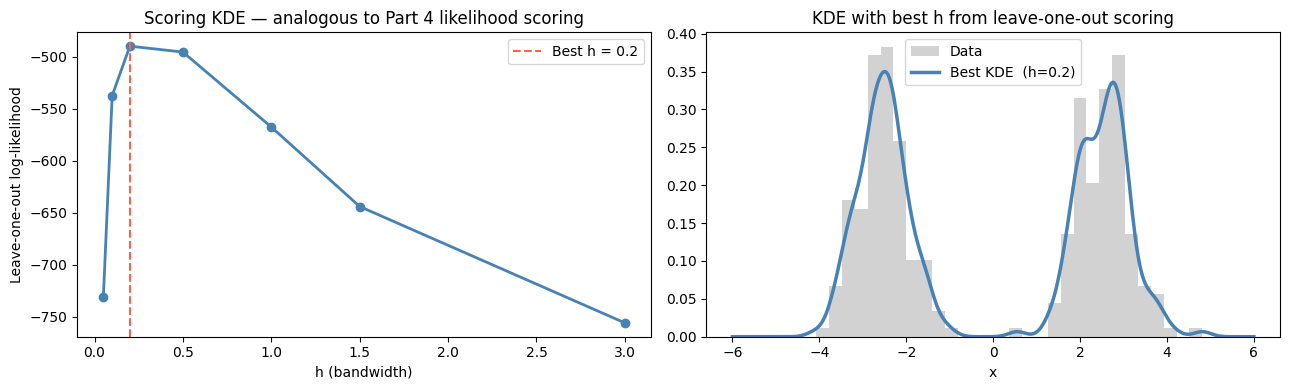

Best bandwidth: h = 0.2


In [9]:
h_grid = [0.05, 0.1, 0.2, 0.5, 1.0, 1.5, 3.0]
ll_scores = []

for h_val in h_grid:
    ll = 0.0
    for i, xi in enumerate(data_bimodal):
        # Leave-one-out: exclude xi from its own KDE
        others      = np.delete(data_bimodal, i)
        p_xi        = gaussian_pdf_local(xi, others, h_val).mean()   # scalar
        ll         += np.log(p_xi + 1e-300)
    ll_scores.append(ll)

best_h = h_grid[np.argmax(ll_scores)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(h_grid, ll_scores, 'o-', color='steelblue', lw=2)
axes[0].axvline(best_h, color='tomato', ls='--', lw=1.5, label=f'Best h = {best_h}')
axes[0].set_xlabel('h (bandwidth)'); axes[0].set_ylabel('Leave-one-out log-likelihood')
axes[0].set_title('Scoring KDE — analogous to Part 4 likelihood scoring')
axes[0].legend()

# Show the best KDE
best_kde = np.array([gaussian_pdf_local(x_plot, xi, best_h) for xi in data_bimodal]).mean(axis=0)
axes[1].hist(data_bimodal, bins=30, density=True, alpha=0.35, color='gray', label='Data')
axes[1].plot(x_plot, best_kde, 'steelblue', lw=2.5, label=f'Best KDE  (h={best_h})')
axes[1].set_title('KDE with best h from leave-one-out scoring')
axes[1].set_xlabel('x'); axes[1].legend()

plt.tight_layout(); plt.show()
print(f'Best bandwidth: h = {best_h}')

### Part 6.4 — Automatic h: Silverman's Rule (Analogous to Part 5)

In Part 5, gradient descent found $\hat{\mu}$ and $\hat{\sigma}$ automatically.
For KDE, there is no gradient descent — there are no parameters to optimize.
Instead, a simple closed-form rule gives a good $h$ directly from the data:

$$h_{\text{Silverman}} = 1.06 \cdot \hat{\sigma} \cdot N^{-1/5}$$

where $\hat{\sigma}$ is the standard deviation of the data and $N$ is the number of points.
This is the default used by `scipy.stats.gaussian_kde`.

It works well when the data is roughly unimodal.
For strongly multimodal data it over-smooths — which is why the leave-one-out
scoring above is more reliable.


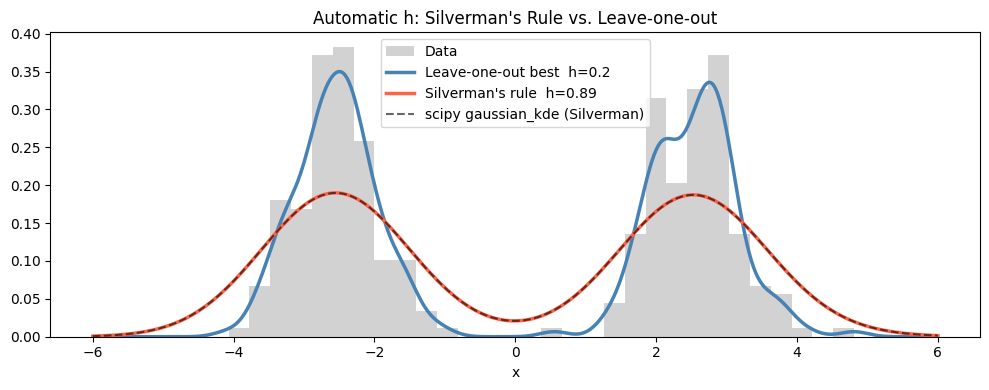

Silverman's h = 1.06 × 2.61 × 300^(-1/5) = 0.885
scipy bandwidth factor = 0.339  (matches Silverman)

For bimodal data, Silverman over-smooths slightly — leave-one-out gives a tighter fit.
For unimodal data, Silverman is fast and works well.


In [10]:
# ── Silverman's rule ─────────────────────────────────────────────────────────
h_silverman = 1.06 * data_bimodal.std() * len(data_bimodal) ** (-1/5)

# ── scipy uses Silverman by default ──────────────────────────────────────────
from scipy.stats import gaussian_kde as scipy_kde
kde_scipy = scipy_kde(data_bimodal, bw_method='silverman')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(data_bimodal, bins=30, density=True, alpha=0.35, color='gray', label='Data')

best_kde = np.array([gaussian_pdf_local(x_plot, xi, best_h)
                     for xi in data_bimodal]).mean(axis=0)
silverman_kde = np.array([gaussian_pdf_local(x_plot, xi, h_silverman)
                          for xi in data_bimodal]).mean(axis=0)

ax.plot(x_plot, best_kde,      'steelblue', lw=2.5, label=f'Leave-one-out best  h={best_h}')
ax.plot(x_plot, silverman_kde, 'tomato',    lw=2.5,
        label=f"Silverman's rule  h={h_silverman:.2f}")
ax.plot(x_plot, kde_scipy(x_plot), 'k--',  lw=1.5, alpha=0.6,
        label='scipy gaussian_kde (Silverman)')

ax.set_title("Automatic h: Silverman's Rule vs. Leave-one-out")
ax.set_xlabel('x'); ax.legend(); plt.tight_layout(); plt.show()

print(f"Silverman's h = 1.06 × {data_bimodal.std():.2f} × {len(data_bimodal)}^(-1/5) "
      f"= {h_silverman:.3f}")
print(f'scipy bandwidth factor = {kde_scipy.factor:.3f}  (matches Silverman)')
print()
print('For bimodal data, Silverman over-smooths slightly — leave-one-out gives a tighter fit.')
print('For unimodal data, Silverman is fast and works well.')

---
## Part 7 — What If Our Data Is Two-Dimensional?

So far every data point was a single number — temperature, height, a test score.
But real data often comes as **pairs**: (height, weight), (latitude, longitude), (pixel brightness, edge strength).

Can a Gaussian handle two dimensions at once? Yes — and it is just as elegant.

Instead of one mean μ and one variance σ², we now have:
- A **mean vector** $\boldsymbol{\mu} \in \mathbb{R}^2$ — where the cloud of points is centered.
- A **covariance matrix** $\boldsymbol{\Sigma} \in \mathbb{R}^{2 \times 2}$ — how spread out the cloud is, and whether the two dimensions are correlated.

The 2D Gaussian PDF is:

$$f(\mathbf{x}) = \frac{1}{2\pi |\boldsymbol{\Sigma}|^{1/2}}
\exp\!\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x}-\boldsymbol{\mu})\right)$$

Two knobs became two richer objects — but the idea is identical.


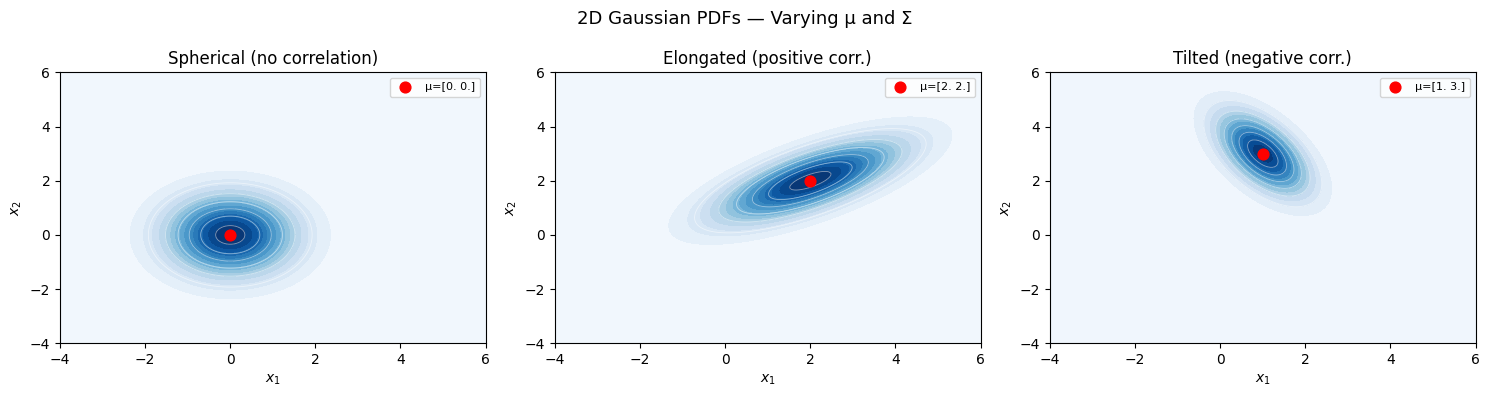

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# ── Grid for evaluating the 2-D PDF ──────────────────────────────────────────
x1 = np.linspace(-4, 6, 200)
x2 = np.linspace(-4, 6, 200)
X1, X2 = np.meshgrid(x1, x2)
pos = np.stack([X1, X2], axis=-1)   # shape (200, 200, 2)

configs = [
    (np.array([0., 0.]),  np.array([[1., 0.],  [0., 1.]]),   'Spherical (no correlation)'),
    (np.array([2., 2.]),  np.array([[2., 1.],  [1., 1.]]),   'Elongated (positive corr.)'),
    (np.array([1., 3.]),  np.array([[0.5, -0.4], [-0.4, 1.]]),'Tilted (negative corr.)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (mu2d, cov2d, title) in zip(axes, configs):
    Z = multivariate_normal(mean=mu2d, cov=cov2d).pdf(pos)
    ax.contourf(X1, X2, Z, levels=15, cmap='Blues')
    ax.contour(X1, X2, Z, levels=6, colors='white', linewidths=0.6, alpha=0.5)
    ax.scatter(*mu2d, color='red', s=60, zorder=5, label=f'μ={mu2d}')
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.legend(fontsize=8)

plt.suptitle('2D Gaussian PDFs — Varying μ and Σ', fontsize=13)
plt.tight_layout()
plt.show()


### Drawing Samples in 2D

Just like in 1D, a 2D Gaussian tells us *where pairs of values are likely to fall*.
Samples cluster around **μ**, and the shape of the cloud is governed by **Σ**.

Let's pick a true distribution and draw some points from it.


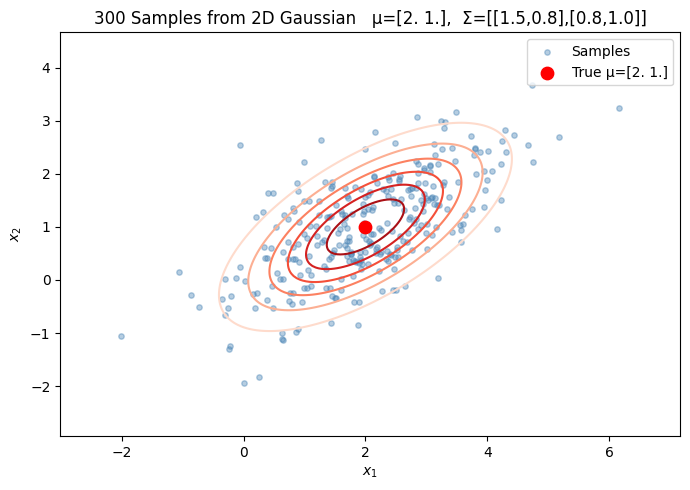

In [10]:
np.random.seed(42)

# ── True parameters ───────────────────────────────────────────────────────────
mu_true_2d  = np.array([2.0, 1.0])
cov_true_2d = np.array([[1.5, 0.8],
                         [0.8, 1.0]])
N2 = 300

data_2d = np.random.multivariate_normal(mu_true_2d, cov_true_2d, N2)

# ── Plot samples + true density contours ─────────────────────────────────────
x1 = np.linspace(data_2d[:,0].min()-1, data_2d[:,0].max()+1, 200)
x2 = np.linspace(data_2d[:,1].min()-1, data_2d[:,1].max()+1, 200)
X1, X2 = np.meshgrid(x1, x2)
pos = np.stack([X1, X2], axis=-1)
Z_true = multivariate_normal(mean=mu_true_2d, cov=cov_true_2d).pdf(pos)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(data_2d[:,0], data_2d[:,1], alpha=0.4, s=15, color='steelblue', label='Samples')
ax.contour(X1, X2, Z_true, levels=6, cmap='Reds', linewidths=1.5)
ax.scatter(*mu_true_2d, color='red', s=80, zorder=5, label=f'True μ={mu_true_2d}')
ax.set_title(f'300 Samples from 2D Gaussian   μ={mu_true_2d},  Σ=[[1.5,0.8],[0.8,1.0]]')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()
plt.tight_layout()
plt.show()


### Which 2D Gaussian Fits Best?

Just as before — if we didn't know the true parameters, we might guess a few candidates.
Some will clearly miss the data cloud. One will be close.


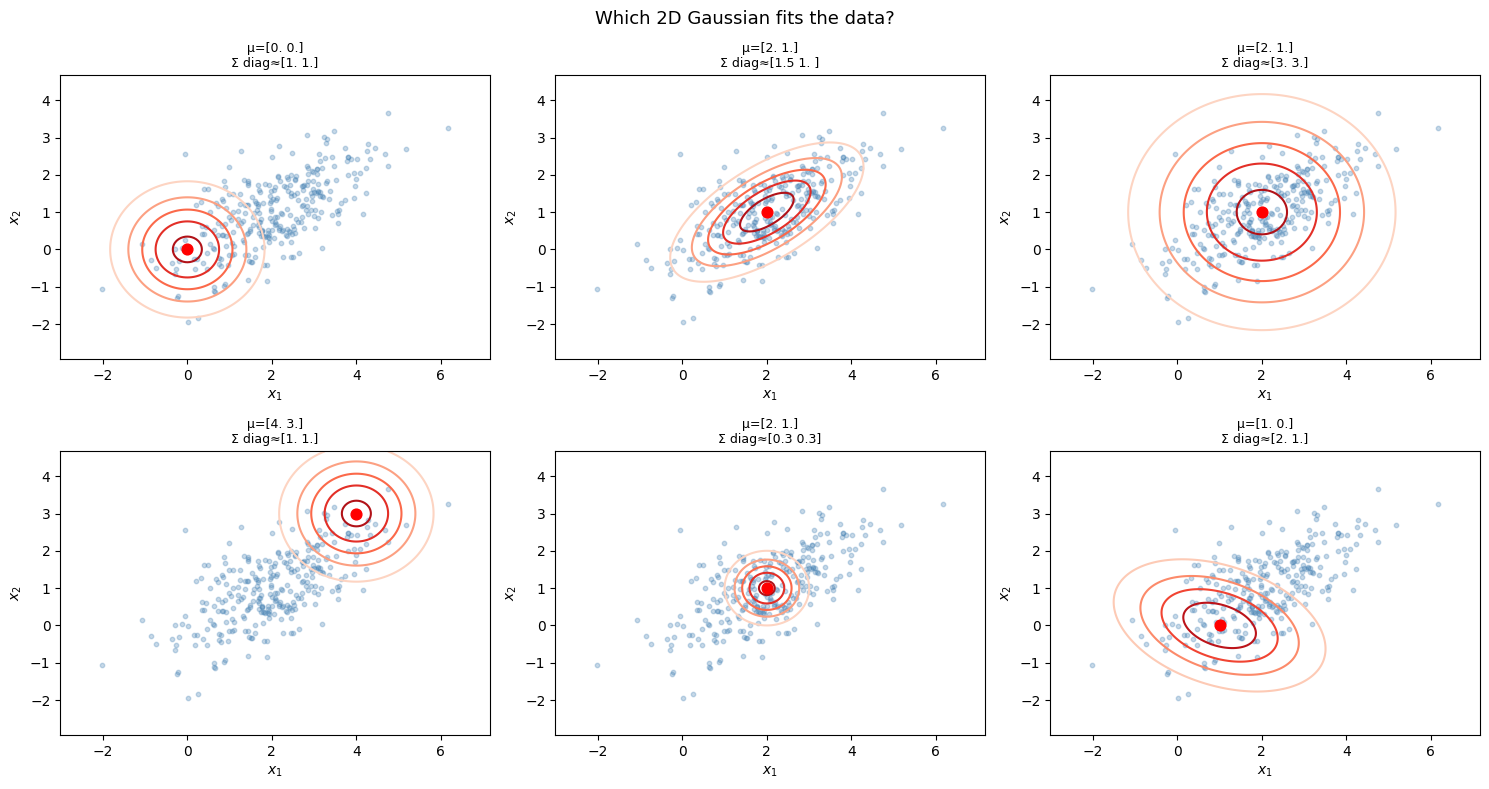

In [11]:
candidates_2d = [
    (np.array([0., 0.]),  np.array([[1., 0.],   [0., 1.]])),
    (np.array([2., 1.]),  np.array([[1.5, 0.8], [0.8, 1.]])),
    (np.array([2., 1.]),  np.array([[3., 0.],   [0., 3.]])),
    (np.array([4., 3.]),  np.array([[1., 0.],   [0., 1.]])),
    (np.array([2., 1.]),  np.array([[0.3, 0.],  [0., 0.3]])),
    (np.array([1., 0.]),  np.array([[2., -0.5], [-0.5, 1.]])),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (mu_c, cov_c) in zip(axes.flat, candidates_2d):
    Z_c = multivariate_normal(mean=mu_c, cov=cov_c).pdf(pos)
    ax.scatter(data_2d[:,0], data_2d[:,1], alpha=0.3, s=10, color='steelblue')
    ax.contour(X1, X2, Z_c, levels=5, cmap='Reds', linewidths=1.5)
    ax.scatter(*mu_c, color='red', s=60, zorder=5)
    ax.set_title(f'μ={mu_c}\nΣ diag≈{np.diag(cov_c)}', fontsize=9)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

plt.suptitle('Which 2D Gaussian fits the data?', fontsize=13)
plt.tight_layout()
plt.show()


### Log-Likelihood in 2D

The log-likelihood extends naturally:

$$\log \mathcal{L}(\boldsymbol{\mu}, \boldsymbol{\Sigma}) =
-\frac{N}{2}\log|2\pi\boldsymbol{\Sigma}|
- \frac{1}{2}\sum_{i=1}^{N}(\mathbf{x}_i - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1}(\mathbf{x}_i - \boldsymbol{\mu})$$

Each data point now contributes a **Mahalanobis distance** to the NLL — a distance that accounts for the shape and orientation of the distribution.

Let's score our six candidates.


In [12]:
def neg_log_likelihood_2d(mu, cov, data):
    """Negative log-likelihood for 2D Gaussian."""
    return -multivariate_normal(mean=mu, cov=cov).logpdf(data).sum()

print(f"{'Candidate':>30}  {'NLL':>12}")
print("-" * 46)
nll_scores = []
for mu_c, cov_c in candidates_2d:
    nll = neg_log_likelihood_2d(mu_c, cov_c, data_2d)
    nll_scores.append(nll)
    print(f"μ={mu_c}, Σ diag={np.diag(cov_c)}  {nll:>12.2f}")

best_idx = int(np.argmin(nll_scores))
print(f"\nBest candidate: μ={candidates_2d[best_idx][0]}, Σ diag={np.diag(candidates_2d[best_idx][1])}")


                     Candidate           NLL
----------------------------------------------
μ=[0. 0.], Σ diag=[1. 1.]       1669.82
μ=[2. 1.], Σ diag=[1.5 1. ]        811.87
μ=[2. 1.], Σ diag=[3. 3.]        999.94
μ=[4. 3.], Σ diag=[1. 1.]       2096.59
μ=[2. 1.], Σ diag=[0.3 0.3]       1380.06
μ=[1. 0.], Σ diag=[2. 1.]       1333.36

Best candidate: μ=[2. 1.], Σ diag=[1.5 1. ]


### Gradient Descent to Fit the 2D Gaussian

Same idea as before — but now we optimize a 2D mean vector and a covariance matrix.

Covariance matrices must stay **symmetric positive-definite** throughout training.
A clean trick: parameterize Σ = L Lᵀ where L is a lower-triangular matrix with positive diagonal
(Cholesky factorization). This keeps Σ valid automatically — no constraints needed.

We'll start from a bad spherical guess and watch it morph into the true tilted ellipse.


In [13]:
import torch

X2d = torch.tensor(data_2d, dtype=torch.float32)   # (N, 2)

# ── Initialization — bad spherical guess ─────────────────────────────────────
mu2d = torch.tensor([0.0, 0.0], requires_grad=True)

# Cholesky factor L: lower-triangular with positive diagonal (via log)
L_diag = torch.tensor([0.0, 0.0], requires_grad=True)   # log of diagonal entries
L_off  = torch.tensor([0.0],      requires_grad=True)   # single off-diagonal entry

def build_L():
    """Reconstruct lower-triangular Cholesky factor."""
    L = torch.zeros(2, 2)
    L[0, 0] = torch.exp(L_diag[0])
    L[1, 1] = torch.exp(L_diag[1])
    L[1, 0] = L_off[0]
    return L

optimizer2d = torch.optim.Adam([mu2d, L_diag, L_off], lr=0.05)

n_epochs2d     = 400
record_every2d = 40
history2d      = []   # (epoch, mu_np, cov_np, nll)

# ── Training loop ─────────────────────────────────────────────────────────────
for epoch in range(n_epochs2d):
    L   = build_L()
    Sig = L @ L.t()                       # Σ = L Lᵀ  (always PSD)
    Sig_inv = torch.linalg.inv(Sig)
    log_det = 2 * L_diag.sum()            # log|Σ| = 2 * sum(log diag L)

    diff = X2d - mu2d                     # (N, 2)
    mahal = (diff @ Sig_inv * diff).sum(dim=1)  # (N,)
    nll2d = 0.5 * (2 * torch.log(torch.tensor(2 * torch.pi)) + log_det + mahal).mean()

    optimizer2d.zero_grad()
    nll2d.backward()
    optimizer2d.step()

    if epoch % record_every2d == 0 or epoch == n_epochs2d - 1:
        history2d.append((
            epoch,
            mu2d.detach().numpy().copy(),
            Sig.detach().numpy().copy(),
            nll2d.item()
        ))

# ── Training log ─────────────────────────────────────────────────────────────
print(f"{'Epoch':>6}  {'μ':>18}  {'Σ diag':>18}  {'NLL':>10}")
print("-" * 60)
for ep, mu_v, cov_v, nll_v in history2d:
    print(f"{ep:>6}  {str(np.round(mu_v,3)):>18}  {str(np.round(np.diag(cov_v),3)):>18}  {nll_v:>10.4f}")

print(f"\nLearned  μ = {history2d[-1][1].round(3)}")
print(f"True     μ = {mu_true_2d}")
print(f"\nLearned  Σ =\n{history2d[-1][2].round(3)}")
print(f"True     Σ =\n{cov_true_2d}")


 Epoch                   μ              Σ diag         NLL
------------------------------------------------------------
     0         [0.05 0.05]             [1. 1.]      5.5661
    40       [1.344 0.587]       [3.043 1.454]      2.8954
    80       [1.939 0.958]       [1.604 0.971]      2.7095
   120       [2.031 1.008]       [1.435 0.931]      2.7043
   160       [2.017 1.   ]       [1.441 0.938]      2.7042
   200       [2.019 1.001]       [1.442 0.938]      2.7042
   240       [2.019 1.001]       [1.441 0.938]      2.7042
   280       [2.019 1.001]       [1.442 0.938]      2.7042
   320       [2.019 1.001]       [1.442 0.938]      2.7042
   360       [2.019 1.001]       [1.442 0.938]      2.7042
   399       [2.019 1.001]       [1.442 0.938]      2.7042

Learned  μ = [2.019 1.001]
True     μ = [2. 1.]

Learned  Σ =
[[1.442 0.766]
 [0.766 0.938]]
True     Σ =
[[1.5 0.8]
 [0.8 1. ]]


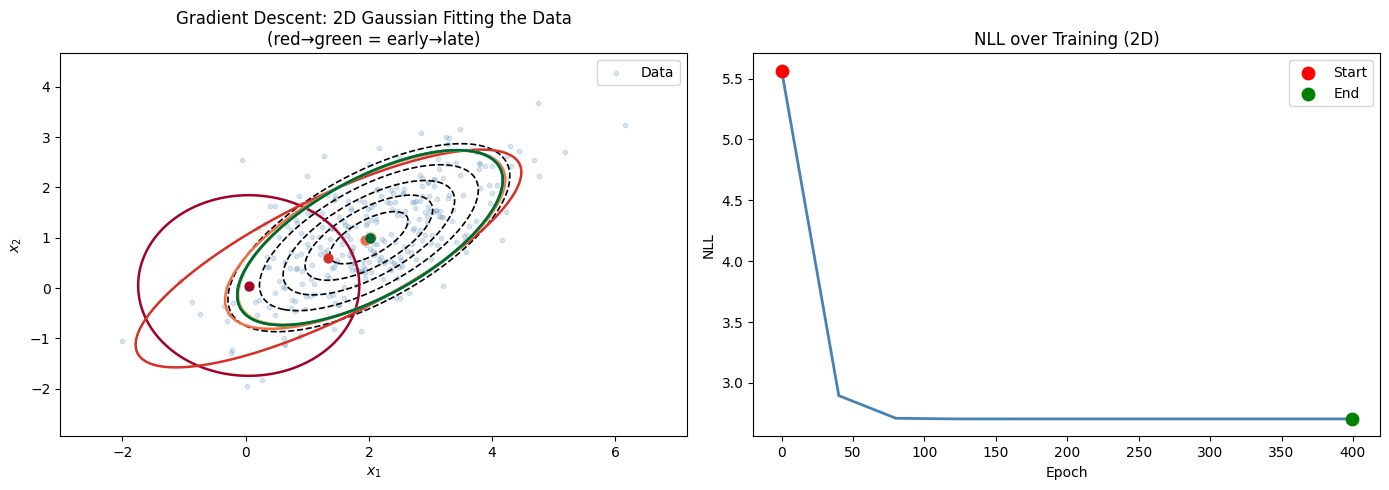

In [14]:
# ── Static snapshot plot ─────────────────────────────────────────────────────
fig2, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5))

n_snap = len(history2d)
cmap2  = plt.cm.RdYlGn

ax_l.scatter(data_2d[:,0], data_2d[:,1], alpha=0.2, s=10, color='steelblue', label='Data')
ax_l.contour(X1, X2, Z_true, levels=5, colors='black',
             linestyles='--', linewidths=1.2)

for i, (ep, mu_v, cov_v, _) in enumerate(history2d):
    Z_snap = multivariate_normal(mean=mu_v, cov=cov_v).pdf(pos)
    color  = cmap2(i / (n_snap - 1))
    ax_l.contour(X1, X2, Z_snap, levels=[Z_snap.max() * 0.2],
                 colors=[color], linewidths=1.8)
    ax_l.scatter(*mu_v, color=color, s=40, zorder=5)

ax_l.set_title('Gradient Descent: 2D Gaussian Fitting the Data\n(red→green = early→late)')
ax_l.set_xlabel('$x_1$')
ax_l.set_ylabel('$x_2$')
ax_l.legend()

epochs2d_rec = [h[0] for h in history2d]
nlls2d_rec   = [h[3] for h in history2d]
ax_r.plot(epochs2d_rec, nlls2d_rec, color='steelblue', linewidth=2)
ax_r.scatter([epochs2d_rec[0]],  [nlls2d_rec[0]],  color='red',   s=80, zorder=5, label='Start')
ax_r.scatter([epochs2d_rec[-1]], [nlls2d_rec[-1]], color='green', s=80, zorder=5, label='End')
ax_r.set_title('NLL over Training (2D)')
ax_r.set_xlabel('Epoch')
ax_r.set_ylabel('NLL')
ax_r.legend()

plt.tight_layout()
plt.show()


### Animation — Watching the 2D Gaussian Converge

Each frame shows the learned contour (one level set) and the estimated mean moving
toward the true distribution (dashed black contour).


Saved: training_animation_2d.gif


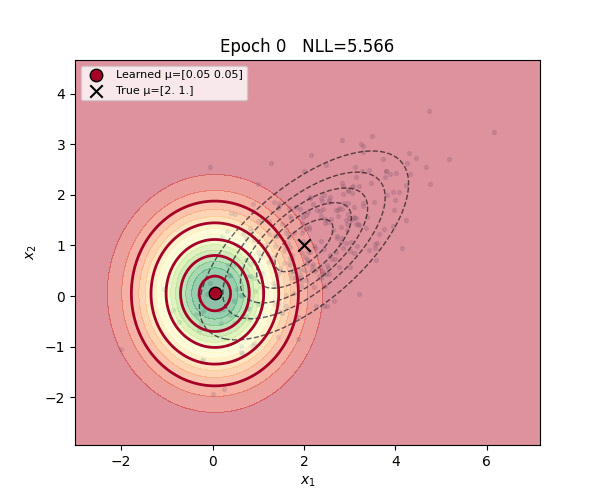

In [15]:
import matplotlib.animation as animation
from IPython.display import Image as IPImage, display

fig_anim2, ax_a2 = plt.subplots(figsize=(6, 5))

def draw_frame_2d(i):
    ax_a2.clear()
    ep, mu_v, cov_v, nll_v = history2d[i]
    color = plt.cm.RdYlGn(i / (len(history2d) - 1))

    Z_snap = multivariate_normal(mean=mu_v, cov=cov_v).pdf(pos)

    ax_a2.scatter(data_2d[:,0], data_2d[:,1], alpha=0.2, s=8, color='steelblue')
    ax_a2.contour(X1, X2, Z_true,  levels=5, colors='black',
                  linestyles='--', linewidths=1.0, alpha=0.6)
    ax_a2.contourf(X1, X2, Z_snap, levels=15, cmap='RdYlGn', alpha=0.45)
    ax_a2.contour(X1, X2, Z_snap,  levels=5,  colors=[color], linewidths=2)
    ax_a2.scatter(*mu_v, color=color, edgecolors='black', s=80, zorder=6,
                  label=f'Learned μ={np.round(mu_v,2)}')
    ax_a2.scatter(*mu_true_2d, color='black', marker='x', s=80, zorder=6,
                  label=f'True μ={mu_true_2d}')

    ax_a2.set_xlim(x1[0], x1[-1])
    ax_a2.set_ylim(x2[0], x2[-1])
    ax_a2.set_title(f'Epoch {ep}   NLL={nll_v:.3f}')
    ax_a2.set_xlabel('$x_1$')
    ax_a2.set_ylabel('$x_2$')
    ax_a2.legend(fontsize=8, loc='upper left')

ani2 = animation.FuncAnimation(
    fig_anim2, draw_frame_2d,
    frames=len(history2d), interval=500, repeat=True
)

gif2_path = 'training_animation_2d.gif'
ani2.save(gif2_path, writer='pillow', fps=2)
plt.close(fig_anim2)

print(f'Saved: {gif2_path}')
display(IPImage(filename=gif2_path))


---
## Part 8 — Application: Generating Images with KDE

We have learned to fit a Gaussian to 1D data, then 2D data.
But here is a question worth sitting with:

> *A grayscale image of size 28×28 is just a vector of 784 numbers.
Is it not just a point in a very high-dimensional space?*

Yes. Every image is a point. A dataset of images is a cloud of points — in 784 dimensions.

If we could fit a distribution over that cloud, we could **sample new points from it — and those new points would be new images**.

That is the dream of generative modeling. And Gaussian KDE can already do a simple version of it.

The trick: 784 dimensions is too many for KDE directly. But most of the variation in handwritten
digits lives in a much lower-dimensional space. We use **PCA** to compress each image to 2 numbers,
fit a **2D KDE** over that compressed space, sample from it, then uncompress back to pixels.

Even this simple pipeline — PCA + KDE — can generate recognizable new images.


Loading MNIST...
Dataset: 14780 images  (6903 zeros, 7877 ones)


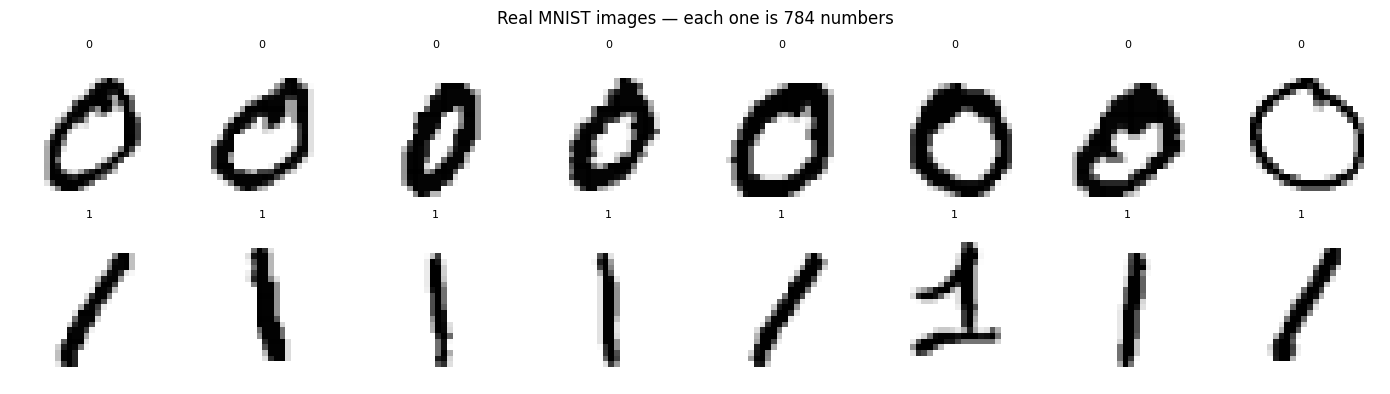

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA

# ── Load MNIST (digits 0 and 1 for cleaner separation) ───────────────────────
print('Loading MNIST...')
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_all, y_all = mnist.data / 255.0, mnist.target.astype(int)

# Keep digits 0 and 1 (visually distinct, makes the demo crisp)
mask  = (y_all == 0) | (y_all == 1)
X_raw = X_all[mask]          # shape (N, 784)
y_raw = y_all[mask]
print(f'Dataset: {X_raw.shape[0]} images  ({(y_raw==0).sum()} zeros, {(y_raw==1).sum()} ones)')

# ── Show a few real images ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, idx in zip(axes[0], np.where(y_raw == 0)[0][:8]):
    ax.imshow(X_raw[idx].reshape(28, 28), cmap='gray_r')
    ax.axis('off')
    ax.set_title('0', fontsize=8)
for ax, idx in zip(axes[1], np.where(y_raw == 1)[0][:8]):
    ax.imshow(X_raw[idx].reshape(28, 28), cmap='gray_r')
    ax.axis('off')
    ax.set_title('1', fontsize=8)
plt.suptitle('Real MNIST images — each one is 784 numbers', fontsize=12)
plt.tight_layout()
plt.show()


### Why Not Fit KDE Directly in 784 Dimensions?

Fair question. We already know how to fit a Gaussian — why not skip PCA and fit a 784-dimensional
Gaussian KDE directly to the raw images?

Three reasons it breaks down:

**1. Computational Cost — The Covariance Matrix**

The 784-D Gaussian PDF requires a **covariance matrix** $\boldsymbol{\Sigma} \in \mathbb{R}^{784 \times 784}$.
That is $784^2 = 614{,}656$ parameters just to store $\boldsymbol{\Sigma}$.

Every time we evaluate the PDF at one point $\mathbf{x}$, we must compute:

$$f(\mathbf{x}) \propto |\boldsymbol{\Sigma}|^{-1/2} \exp\!\left(-\tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x}-\boldsymbol{\mu})\right)$$

This requires $\boldsymbol{\Sigma}^{-1}$ — a **matrix inverse** that costs $\mathcal{O}(d^3)$ operations.
For $d=784$: that is $784^3 \approx 481{,}000{,}000$ floating-point operations **per kernel evaluation**.
KDE evaluates one kernel *per training point* per query — with 10,000 images and 10,000 queries:
$10{,}000 \times 10{,}000 \times 481\text{M} \approx 10^{16}$ operations. Completely intractable.

**2. The Curse of Dimensionality**

Even if we could afford it, KDE would fail statistically.
In $d$ dimensions, a Gaussian bump with bandwidth $h$ covers a volume of $\sim h^d$.
As $d$ grows, that volume shrinks *exponentially*.
With $d=784$, bumps become vanishingly thin — no two bumps ever meaningfully
overlap, so there is no smoothing. Every training image becomes an isolated spike.
Sampling from it is the same as randomly picking a training image.

**3. You Need Exponentially More Data**

To cover a $d$-dimensional space at density $\rho$ you need $\sim \rho^d$ samples.
MNIST has 60,000 images. For 784D at the same coverage as 2D: $10^{300+}$ images needed.

A quick illustration — both the computational cost and the geometric collapse:


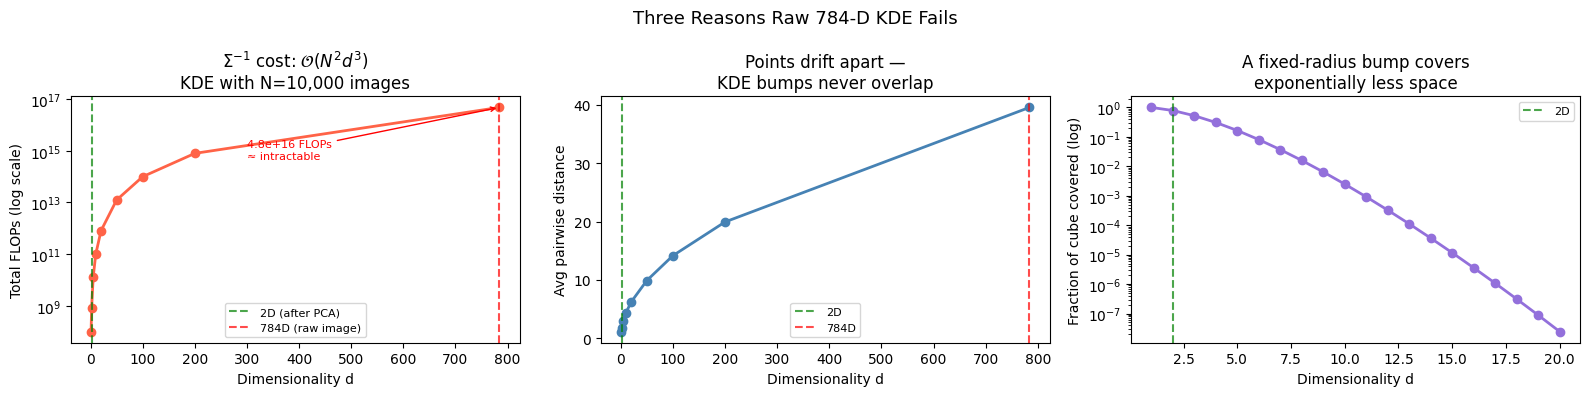

784-D KDE inversion cost per query: 784^3 = 481,890,304 FLOPs
Full KDE evaluation (N=10k train, N=10k query): 4.82e+16 FLOPs
By comparison, 2-D KDE: 800,000,000 FLOPs  (6e+07x cheaper)


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

np.random.seed(0)
dims = [1, 2, 5, 10, 20, 50, 100, 200, 784]

# ── 1. Covariance matrix inversion cost: O(d^3) ───────────────────────────────
# For KDE with N training points, N queries: N * N * d^3 operations
N = 10_000
flops = [N * N * d**3 for d in dims]

# ── 2. Average pairwise distance grows with d ─────────────────────────────────
n_pts = 300
avg_dists = []
for d in dims:
    pts   = np.random.randn(n_pts, d)
    diffs = pts[:, None, :] - pts[None, :, :]
    dists = np.linalg.norm(diffs, axis=-1)
    upper = dists[np.triu_indices(n_pts, k=1)]
    avg_dists.append(upper.mean())

# ── 3. Fraction of space covered by a unit ball ───────────────────────────────
d_range  = np.arange(1, 21)
ball_vol = np.pi**(d_range/2) / gamma(d_range/2 + 1)
cube_vol = 2**d_range
frac     = ball_vol / cube_vol

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: compute cost
axes[0].semilogy(dims, flops, 'o-', color='tomato', linewidth=2)
axes[0].axvline(2,   color='green', linestyle='--', alpha=0.7, label='2D (after PCA)')
axes[0].axvline(784, color='red',   linestyle='--', alpha=0.7, label='784D (raw image)')
axes[0].set_xlabel('Dimensionality d')
axes[0].set_ylabel('Total FLOPs (log scale)')
axes[0].set_title(r'$\Sigma^{-1}$ cost: $\mathcal{O}(N^2 d^3)$' + '\nKDE with N=10,000 images')
axes[0].legend(fontsize=8)

# Annotate the 784D cost
axes[0].annotate(
    f'{flops[-1]:.1e} FLOPs\n≈ intractable',
    xy=(784, flops[-1]), xytext=(300, flops[-1]*1e-2),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=8, color='red'
)

# Panel 2: points drift apart
axes[1].plot(dims, avg_dists, 'o-', color='steelblue', linewidth=2)
axes[1].axvline(2,   color='green', linestyle='--', alpha=0.7, label='2D')
axes[1].axvline(784, color='red',   linestyle='--', alpha=0.7, label='784D')
axes[1].set_xlabel('Dimensionality d')
axes[1].set_ylabel('Avg pairwise distance')
axes[1].set_title('Points drift apart —\nKDE bumps never overlap')
axes[1].legend(fontsize=8)

# Panel 3: fraction of space covered
axes[2].semilogy(d_range, frac, 'o-', color='mediumpurple', linewidth=2)
axes[2].axvline(2, color='green', linestyle='--', alpha=0.7, label='2D')
axes[2].set_xlabel('Dimensionality d')
axes[2].set_ylabel('Fraction of cube covered (log)')
axes[2].set_title('A fixed-radius bump covers\nexponentially less space')
axes[2].legend(fontsize=8)

plt.suptitle('Three Reasons Raw 784-D KDE Fails', fontsize=13)
plt.tight_layout()
plt.show()

print(f'784-D KDE inversion cost per query: 784^3 = {784**3:,} FLOPs')
print(f'Full KDE evaluation (N=10k train, N=10k query): {N*N*784**3:.2e} FLOPs')
print(f'By comparison, 2-D KDE: {N*N*2**3:,} FLOPs  ({N*N*784**3 / (N*N*2**3):.0e}x cheaper)')


### Step 1 — Compress to 2D with PCA

PCA finds the two directions in pixel-space that capture the most variation across all images.
Projecting onto those two directions gives us a 2D *fingerprint* for each image.
Images that look similar end up close together in this 2D space.


Explained variance: PC1=32.2%,  PC2=9.0%
Total captured: 41.2% of variation


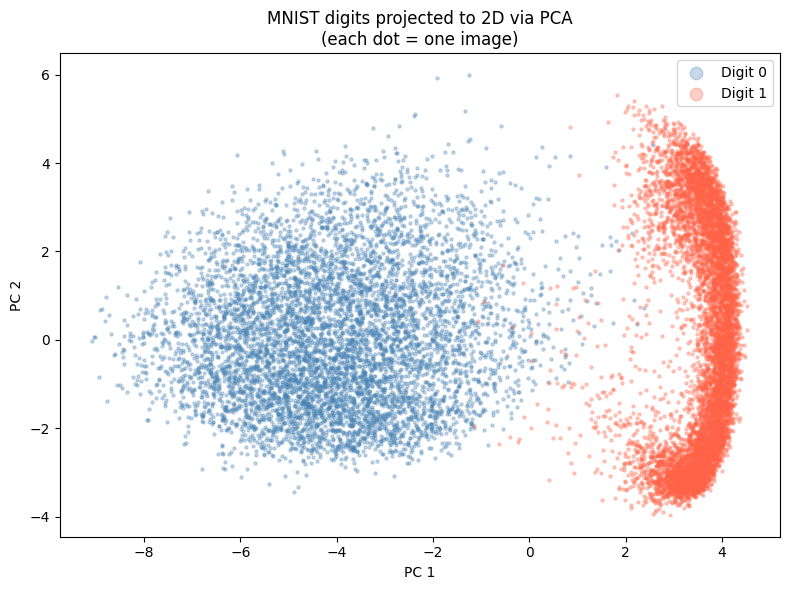

In [17]:
# ── Fit PCA: 784-D → 2-D ─────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_raw)   # shape (N, 2)

print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%},  '
      f'PC2={pca.explained_variance_ratio_[1]:.1%}')
print(f'Total captured: {pca.explained_variance_ratio_.sum():.1%} of variation')

# ── Scatter plot of the 2D PCA space ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: 'steelblue', 1: 'tomato'}
for digit in [0, 1]:
    idx = y_raw == digit
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
               c=colors[digit], alpha=0.3, s=5, label=f'Digit {digit}')

ax.set_title('MNIST digits projected to 2D via PCA\n(each dot = one image)')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()


### Step 2a — Fit a Single 2D Gaussian via Gradient Descent

We now have 2D data — the PCA fingerprints of each image.
This is exactly the setting from Part 6: a cloud of 2D points.

Let's apply the same procedure: parameterize $\boldsymbol{\Sigma} = \mathbf{L}\mathbf{L}^\top$ (Cholesky),
optimize $\boldsymbol{\mu}$ and $\mathbf{L}$ with Adam by minimizing the 2D Gaussian NLL:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^N \log f(\mathbf{x}_i \mid \boldsymbol{\mu}, \boldsymbol{\Sigma})
= \frac{1}{2}\left(\log|2\pi\boldsymbol{\Sigma}| + \overline{(\mathbf{x}-\boldsymbol{\mu})^\top\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})}\right)$$

We do this separately for digit 0 and digit 1.


In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def fit_gaussian_2d(X_np, n_epochs=400, record_every=40, lr=0.05):
    """Fit a 2D Gaussian to X_np via gradient descent (Cholesky parameterization)."""
    X_t = torch.tensor(X_np, dtype=torch.float32)

    # ── Initialization — bad spherical guess ─────────────────────────────────
    mu      = torch.tensor([0.0, 0.0], requires_grad=True)
    L_diag  = torch.tensor([0.0, 0.0], requires_grad=True)  # log of diag entries
    L_off   = torch.tensor([0.0],      requires_grad=True)  # off-diagonal

    def build_L():
        L = torch.zeros(2, 2)
        L[0, 0] = torch.exp(L_diag[0])
        L[1, 1] = torch.exp(L_diag[1])
        L[1, 0] = L_off[0]
        return L

    opt     = torch.optim.Adam([mu, L_diag, L_off], lr=lr)
    history = []  # (epoch, mu_np, cov_np, nll)

    for epoch in range(n_epochs):
        L       = build_L()
        Sig     = L @ L.t()
        Sig_inv = torch.linalg.inv(Sig)
        log_det = 2 * L_diag.sum()           # log|Σ| = 2·Σ log diag(L)

        diff  = X_t - mu                     # (N, 2)
        mahal = (diff @ Sig_inv * diff).sum(dim=1)  # (N,)
        nll   = 0.5 * (2 * torch.log(torch.tensor(2 * torch.pi)) + log_det + mahal).mean()

        opt.zero_grad()
        nll.backward()
        opt.step()

        if epoch % record_every == 0 or epoch == n_epochs - 1:
            history.append((
                epoch,
                mu.detach().numpy().copy(),
                Sig.detach().numpy().copy(),
                nll.item()
            ))

    return history

# ── Fit one Gaussian per digit ────────────────────────────────────────────────
histories_app = {}
for digit in [0, 1]:
    X_digit = X_2d[y_raw == digit]
    histories_app[digit] = fit_gaussian_2d(X_digit)
    ep, mu_v, cov_v, nll_v = histories_app[digit][-1]
    print(f"Digit {digit}  →  μ={np.round(mu_v,3)}  Σ diag={np.round(np.diag(cov_v),3)}  NLL={nll_v:.4f}")

# ── Training log for digit 0 ─────────────────────────────────────────────────
print(f"\n--- Training log: Digit 0 ---")
print(f"{'Epoch':>6}  {'μ':>18}  {'Σ diag':>18}  {'NLL':>10}")
print('-' * 58)
for ep, mu_v, cov_v, nll_v in histories_app[0]:
    print(f"{ep:>6}  {str(np.round(mu_v,3)):>18}  {str(np.round(np.diag(cov_v),3)):>18}  {nll_v:>10.4f}")


Digit 0  →  μ=[-4.029  0.056]  Σ diag=[3.299 2.365]  NLL=3.8599
Digit 1  →  μ=[ 3.53  -0.049]  Σ diag=[0.335 6.314]  NLL=3.2084

--- Training log: Digit 0 ---
 Epoch                   μ              Σ diag         NLL
----------------------------------------------------------
     0       [-0.05  0.05]             [1. 1.]     12.7857
    40     [-1.302  0.278]       [9.441 2.201]      4.4607
    80     [-1.775  0.255]     [10.46   2.393]      4.3398
   120     [-2.244  0.215]       [8.487 2.41 ]      4.2171
   160     [-2.778  0.166]         [6.36 2.39]      4.0732
   200     [-3.321  0.118]       [4.654 2.376]      3.9421
   240     [-3.747  0.08 ]       [3.658 2.368]      3.8740
   280     [-3.959  0.062]       [3.329 2.365]      3.8607
   320     [-4.019  0.057]       [3.296 2.365]      3.8600
   360     [-4.028  0.056]       [3.299 2.365]      3.8599
   399     [-4.029  0.056]       [3.299 2.365]      3.8599


Visualize the learned Gaussians as contours over the PCA scatter:


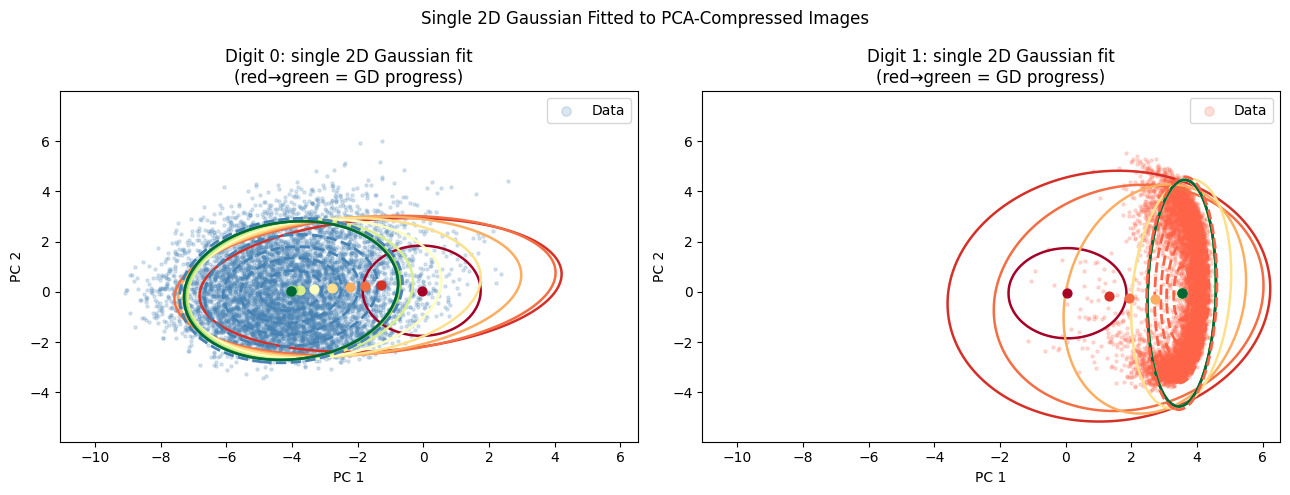

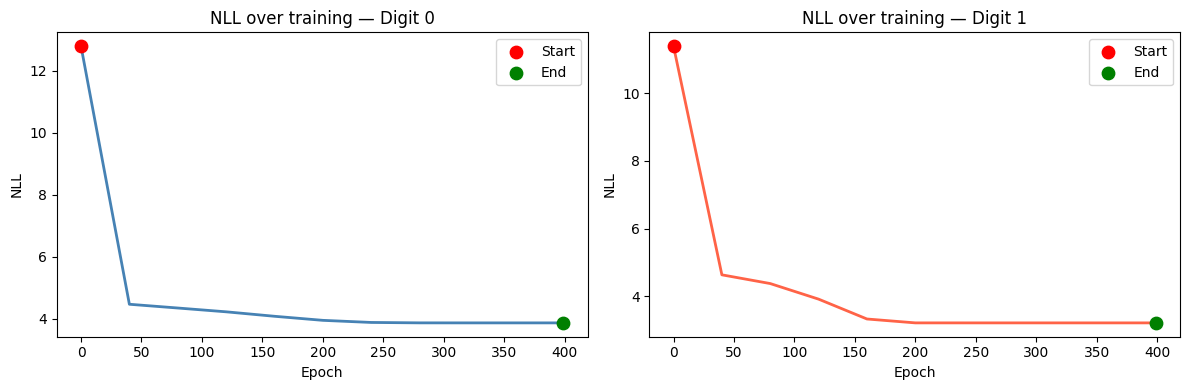

In [24]:
from scipy.stats import multivariate_normal

# ── Grid ──────────────────────────────────────────────────────────────────────
x_min, x_max = X_2d[:,0].min()-2, X_2d[:,0].max()+2
y_min, y_max = X_2d[:,1].min()-2, X_2d[:,1].max()+2
g1 = np.linspace(x_min, x_max, 150)
g2 = np.linspace(y_min, y_max, 150)
G1, G2 = np.meshgrid(g1, g2)
pos = np.stack([G1, G2], axis=-1)   # (150, 150, 2)

# ── Snapshot plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_d = {0: 'steelblue', 1: 'tomato'}
cmaps_d  = {0: 'Blues',     1: 'Reds'}
cmap_traj = plt.cm.RdYlGn

for ax, digit in zip(axes, [0, 1]):
    idx = y_raw == digit
    ax.scatter(X_2d[idx,0], X_2d[idx,1],
               c=colors_d[digit], alpha=0.2, s=5, label='Data')

    hist = histories_app[digit]
    n_snap = len(hist)
    for i, (ep, mu_v, cov_v, _) in enumerate(hist):
        Z     = multivariate_normal(mean=mu_v, cov=cov_v).pdf(pos)
        color = cmap_traj(i / (n_snap - 1))
        ax.contour(G1, G2, Z, levels=[Z.max() * 0.2],
                   colors=[color], linewidths=1.8)
        ax.scatter(*mu_v, color=color, s=40, zorder=5)

    final_mu, final_cov = hist[-1][1], hist[-1][2]
    Z_final = multivariate_normal(mean=final_mu, cov=final_cov).pdf(pos)
    ax.contour(G1, G2, Z_final, levels=5,
               colors=[colors_d[digit]], linewidths=2, linestyles='--')

    ax.set_title(f'Digit {digit}: single 2D Gaussian fit\n(red→green = GD progress)')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.legend(markerscale=3)

plt.suptitle('Single 2D Gaussian Fitted to PCA-Compressed Images', fontsize=12)
plt.tight_layout()
plt.show()

# ── NLL curves ────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
for ax, digit in zip(axes2, [0, 1]):
    eps  = [r[0] for r in histories_app[digit]]
    nlls = [r[3] for r in histories_app[digit]]
    ax.plot(eps, nlls, color=colors_d[digit], linewidth=2)
    ax.scatter([eps[0]],  [nlls[0]],  color='red',   s=80, zorder=5, label='Start')
    ax.scatter([eps[-1]], [nlls[-1]], color='green', s=80, zorder=5, label='End')
    ax.set_title(f'NLL over training — Digit {digit}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('NLL')
    ax.legend()
plt.tight_layout()
plt.show()


### Step 2b — But One Gaussian Is Not Enough

Look at the contours above. The single Gaussian does a decent job capturing the *average* location
and spread of each digit cluster — but it forces the density into one smooth ellipse.

Real image distributions are more complex: within digit 0, some are narrow, some wide,
some tilted. One Gaussian cannot capture that.

**This is exactly the same problem we saw in Part 1 — and the solution is the same:**
instead of one Gaussian, place one at *every training point*. That is Kernel Density Estimation.

Now let's use `scipy.stats.gaussian_kde`, which does exactly this with Silverman's rule for bandwidth:


Digit 0: 6903 images, bandwidth h ≈ 0.229
Digit 1: 7877 images, bandwidth h ≈ 0.224


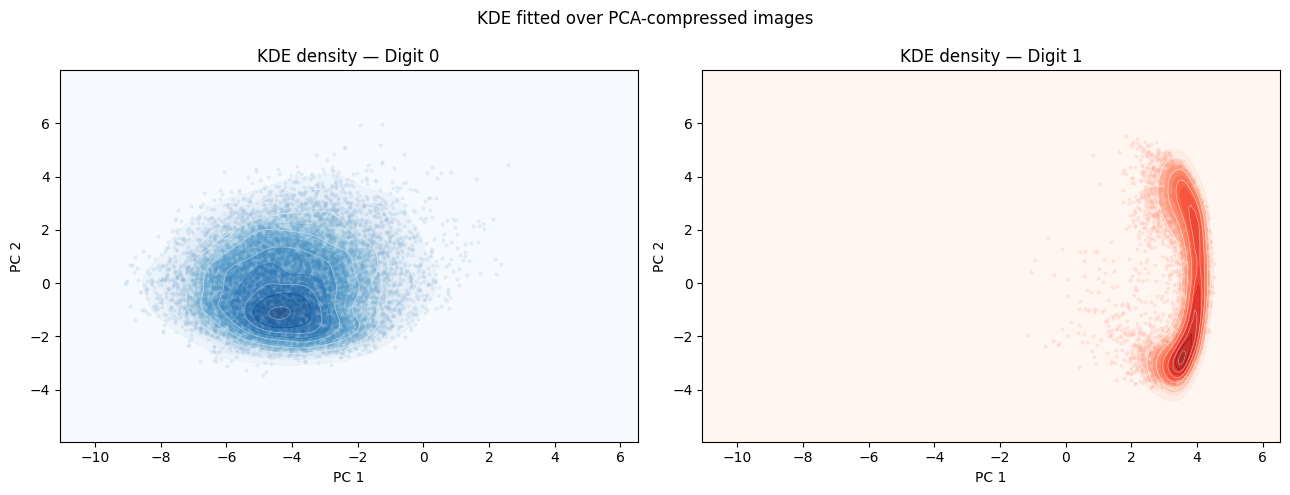

In [25]:
from scipy.stats import gaussian_kde

# ── Fit one KDE per digit ─────────────────────────────────────────────────────
kdes = {}
for digit in [0, 1]:
    pts = X_2d[y_raw == digit].T   # shape (2, N_digit)
    kdes[digit] = gaussian_kde(pts, bw_method='silverman')
    print(f'Digit {digit}: {pts.shape[1]} images, bandwidth h ≈ {kdes[digit].factor:.3f}')

# ── Visualise KDE density surfaces ───────────────────────────────────────────
x_min, x_max = X_2d[:,0].min()-2, X_2d[:,0].max()+2
y_min, y_max = X_2d[:,1].min()-2, X_2d[:,1].max()+2
g1 = np.linspace(x_min, x_max, 150)
g2 = np.linspace(y_min, y_max, 150)
G1, G2 = np.meshgrid(g1, g2)
grid_pts = np.stack([G1.ravel(), G2.ravel()])   # (2, 150*150)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (digit, color, cmap) in zip(axes,
        [(0,'steelblue','Blues'), (1,'tomato','Reds')]):
    Z = kdes[digit](grid_pts).reshape(G1.shape)
    idx = y_raw == digit
    ax.scatter(X_2d[idx,0], X_2d[idx,1], c=color, alpha=0.2, s=4)
    ax.contourf(G1, G2, Z, levels=15, cmap=cmap, alpha=0.6)
    ax.contour(G1, G2, Z,  levels=6,  colors='white', linewidths=0.5, alpha=0.6)
    ax.set_title(f'KDE density — Digit {digit}')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')

plt.suptitle('KDE fitted over PCA-compressed images', fontsize=12)
plt.tight_layout()
plt.show()


### Step 3 — Sample from the KDE and Reconstruct Images

Sampling from a KDE is the same trick we learned earlier:
pick a random training image, add a small Gaussian perturbation (noise ∝ bandwidth h),
and you have a new 2D fingerprint.

Plug that fingerprint into PCA's inverse transform → a new 28×28 image.

**These images were never in the dataset. They were generated by the model.**


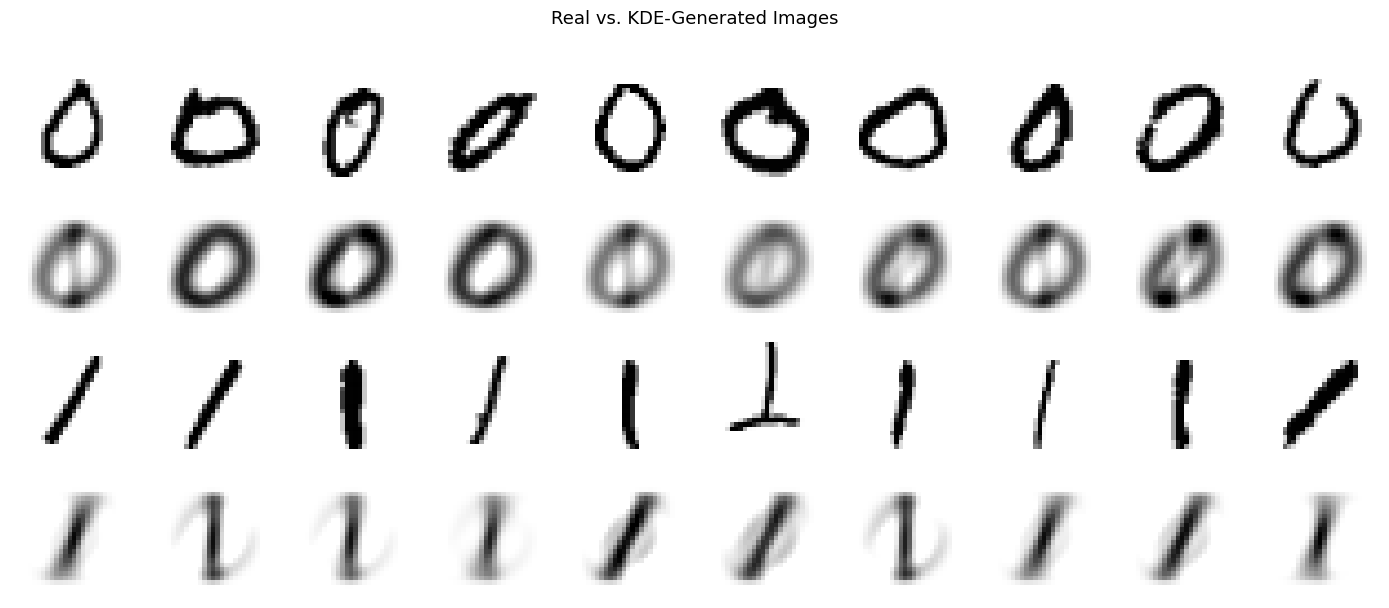

Generated images are blurry — PCA only kept 2 dimensions out of 784.
But the overall shape (round loop vs. vertical stroke) is captured.
More PCA components = sharper images. This is the core idea behind VAE and diffusion models.


In [26]:
np.random.seed(0)
n_generate = 10

fig, axes = plt.subplots(4, n_generate, figsize=(14, 6))
row_labels = ['Real 0', 'Generated 0', 'Real 1', 'Generated 1']

for col_i, digit in enumerate([0, 1]):
    real_row   = col_i * 2       # rows 0, 2
    gen_row    = col_i * 2 + 1  # rows 1, 3

    # ── Real images (random sample from dataset) ───────────────────────────
    real_idx = np.random.choice(np.where(y_raw == digit)[0], n_generate, replace=False)
    for j, idx in enumerate(real_idx):
        axes[real_row, j].imshow(X_raw[idx].reshape(28, 28), cmap='gray_r', vmin=0, vmax=1)
        axes[real_row, j].axis('off')

    # ── Generated images via KDE sampling ─────────────────────────────────
    gen_2d = kdes[digit].resample(n_generate, seed=digit).T   # (n_generate, 2)
    gen_images = pca.inverse_transform(gen_2d)                # (n_generate, 784)
    gen_images = np.clip(gen_images, 0, 1)

    for j, img in enumerate(gen_images):
        axes[gen_row, j].imshow(img.reshape(28, 28), cmap='gray_r', vmin=0, vmax=1)
        axes[gen_row, j].axis('off')

# ── Row labels ────────────────────────────────────────────────────────────────
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=0,
                            labelpad=55, va='center')

plt.suptitle('Real vs. KDE-Generated Images', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Generated images are blurry — PCA only kept 2 dimensions out of 784.')
print('But the overall shape (round loop vs. vertical stroke) is captured.')
print('More PCA components = sharper images. This is the core idea behind VAE and diffusion models.')


### Bonus — KDE for Anomaly Detection

Once we have a fitted density, we can also ask: *how likely is a new image?*

If a new image gets a very low KDE score, it is probably unlike anything in the training set —
an **anomaly**. This is the simplest possible one-class classifier:

> Score new image → low density → flag as anomaly.

Let's test: give the digit-0 KDE some digit-1 images (which should look anomalous to it),
and compare their scores to genuine digit-0 images.


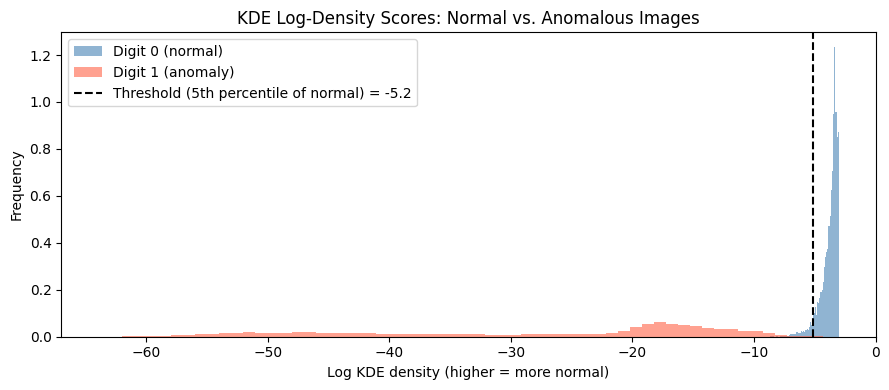

Detection rate  (digit 1 flagged as anomaly): 99.9%
False alarm rate (digit 0 flagged as anomaly): 5.0%

A simple KDE threshold already separates the two digit classes reasonably well.
No labels needed during training — just the normal data distribution.


In [27]:
# ── Score normal (digit 0) and anomalous (digit 1) images under KDE_0 ────────
pts_0 = X_2d[y_raw == 0].T   # normal
pts_1 = X_2d[y_raw == 1].T   # anomalies from the perspective of KDE_0

scores_normal = np.log(kdes[0](pts_0) + 1e-300)   # log-density
scores_anomal = np.log(kdes[0](pts_1) + 1e-300)

# ── Histogram of scores ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scores_normal, bins=60, density=True, alpha=0.6,
        color='steelblue', label='Digit 0 (normal)')
ax.hist(scores_anomal, bins=60, density=True, alpha=0.6,
        color='tomato',    label='Digit 1 (anomaly)')
threshold = np.percentile(scores_normal, 5)   # flag bottom 5% as anomaly
ax.axvline(threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold (5th percentile of normal) = {threshold:.1f}')
ax.set_title('KDE Log-Density Scores: Normal vs. Anomalous Images')
ax.set_xlabel('Log KDE density (higher = more normal)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

tp = (scores_anomal < threshold).mean()   # fraction of digit-1 correctly flagged
fp = (scores_normal < threshold).mean()   # fraction of digit-0 incorrectly flagged
print(f'Detection rate  (digit 1 flagged as anomaly): {tp:.1%}')
print(f'False alarm rate (digit 0 flagged as anomaly): {fp:.1%}')
print()
print('A simple KDE threshold already separates the two digit classes reasonably well.')
print('No labels needed during training — just the normal data distribution.')


### What We Just Did — and Why It Matters

| Step | Tool | What it does |
|------|------|--------------|
| Compress | PCA | 784-D image → 2-D fingerprint |
| Model | Gaussian KDE | Learn a smooth density over fingerprints |
| Generate | KDE sampling | New fingerprint → new image |
| Detect | KDE score | Low density → anomaly |

The generated images are blurry because PCA kept only 2 dimensions.
But the **structure is there** — zeros look round, ones look like strokes.

This is exactly the intuition behind every modern generative model:
- **VAE**: learns a better compressed space (non-linear PCA) + fits a Gaussian over it.
- **GAN**: learns to sample from a complex distribution without ever writing it down explicitly.
- **Diffusion**: learns to add and remove noise, which is equivalent to sampling from a very flexible density.

Gaussian KDE is the simplest possible version of all of them — and it already works.


## Wrap-Up

In just 300 steps, gradient descent found μ ≈ 3.0 and σ ≈ 1.0 — exactly the true parameters.

This is **Maximum Likelihood Estimation (MLE)** done via optimization. Instead of closed-form formulas, we used automatic differentiation and Adam to navigate the loss landscape. The two approaches converge to the same answer, but the gradient-descent framing generalizes to any model where closed forms don't exist.

**Coming up next:** What if the data is not unimodal? What if it has multiple peaks? One Gaussian won't cut it — and that's exactly where Kernel Density Estimation comes in.